# Credit Card Fraud Detection using Machine Learning - By Tejashri Pilla

## Capstone Project

In today’s digital economy, credit card transactions have grown exponentially, making fraud detection a critical problem for financial institutions. Credit card fraud not only results in direct financial losses but also leads to customer dissatisfaction, loss of trust, and increased operational costs.

This project focuses on building a **machine learning–based fraud detection system** using historical transaction data to identify potentially fraudulent transactions with high recall while controlling false positives.


## Problem Statement

The objective of this project is to build a machine learning model that can accurately detect fraudulent credit card transactions based on historical transactional data.

The dataset is highly imbalanced, with fraudulent transactions accounting for less than 1% of the total transactions. This makes the problem challenging, as traditional accuracy-based evaluation can be misleading.

The goal is to design a solution that:
- Maximizes the detection of fraudulent transactions (high recall)
- Minimizes false positives to avoid unnecessary transaction declines
- Is robust, interpretable, and suitable for real-world deployment

## Business Objective

From a business perspective, credit card fraud detection involves balancing two competing costs:

- **False Negatives (Missed Fraud):**  
  Leads to direct financial loss and potential regulatory issues.

- **False Positives (Incorrectly Flagged Legitimate Transactions):**  
  Results in poor customer experience, declined transactions, and customer churn.

Therefore, the primary business objective is to **minimize financial losses due to fraud while maintaining a smooth customer transaction experience**.

This implies that model evaluation should focus on metrics such as recall, precision, and cost-aware trade-offs rather than accuracy alone.


## Machine Learning Objective

The machine learning objective is to build a binary classification model that predicts whether a transaction is fraudulent or not.

- Target variable: `is_fraud`
  - 1 → Fraudulent transaction
  - 0 → Legitimate transaction

Key challenges addressed:
- Severe class imbalance
- Feature engineering from transactional and temporal data
- Selection of appropriate evaluation metrics
- Model interpretability and robustness


## Project Workflow

The project will be executed using the following structured pipeline:

1. Data Loading and Understanding
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis (EDA)
4. Train/Validation Data Splitting
5. Feature Engineering
6. Model Building (Baseline)
7. Handling Class Imbalance
8. Hyperparameter Tuning
9. Model Evaluation (on Test)
10. Final Model Selection
11. Final Model Evaluation (on Unseen data)
12. Model Interpretation
13. Business Impact Analysis
14. Conclusion

## Dataset Description

The dataset used in this project is a simulated credit card transaction dataset obtained from Kaggle.

Key characteristics:
- Transactions from ~1,000 cardholders
- Transactions across ~800 merchants
- Time period: January 2019 – December 2020
- Total transactions: ~1.85 million
- Fraudulent transactions: ~0.52%

Due to the large size of the dataset, it is stored in Google Drive and accessed through Google Colab to ensure reproducibility and smooth execution.


## Environment and Tools

- Platform: Google Colab
- Storage: Google Drive
- Programming Language: Python
- Libraries:
  - pandas, numpy – data manipulation
  - matplotlib, seaborn – visualization
  - scikit-learn – modeling and evaluation
  - imbalanced-learn – handling class imbalance


## Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('default')

# Suppress all warnings
import warnings
warnings.filterwarnings('ignore')

# To get calendar functions
import calendar

import time

# Distance in geographical location
from geopy.distance import geodesic

# 1 - Data Loading and Understanding

In [2]:
# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

## Load the Dataset

In [3]:
#train_data = "/content/drive/MyDrive/Credit_Card_Fraud_Detection/Data/raw/fraudTrain.csv"

#df_train = pd.read_csv(train_data)

df_train = pd.read_csv(r'C:\Users\tejas\Documents\Credit_Card_Fraud_Detection\Data\raw\fraudTrain.csv')

print("Shape of Train data: ", df_train.shape)

Shape of Train data:  (734993, 23)


## Understand the Dataset

In [4]:
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0.0


In [5]:
#checking columns, non-null count and data type
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734993 entries, 0 to 734992
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             734993 non-null  int64  
 1   trans_date_trans_time  734993 non-null  object 
 2   cc_num                 734993 non-null  int64  
 3   merchant               734993 non-null  object 
 4   category               734993 non-null  object 
 5   amt                    734993 non-null  float64
 6   first                  734993 non-null  object 
 7   last                   734993 non-null  object 
 8   gender                 734993 non-null  object 
 9   street                 734993 non-null  object 
 10  city                   734993 non-null  object 
 11  state                  734993 non-null  object 
 12  zip                    734993 non-null  int64  
 13  lat                    734993 non-null  float64
 14  long                   734993 non-nu

🔍 Findings

*   There is one column `Unnamed`, which is just index and there is no need of this.
*   There is column `trans_date_trans_time`, for which data type is object but it should be datetime.
*   `dob` column is of object type, which should be datetime type.
*   `unix_time` represents the timestamp of the transaction in Unix (Epoch) time format, so basically it represents the same information as of `trans_date_trans_time` column.






In [6]:
#checking min, max, mean, std dev values for numerical columns
df_train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,734993.000000,7.349930e+05,734993.000000,734993.000000,734993.000000,734993.000000,7.349930e+05,7.349930e+05,734993.000000,734992.000000,734992.000000
mean,367496.000000,4.164540e+17,70.264056,48776.759535,38.538013,-90.215925,8.909044e+04,1.339714e+09,38.537757,-90.216394,0.005921
std,212174.347538,1.307906e+18,158.135582,26904.518167,5.072953,13.762075,3.030314e+05,7.399242e+06,5.107275,13.774145,0.076721
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.671242,0.000000
25%,183748.000000,1.800365e+14,9.650000,26237.000000,34.668900,-96.798000,7.430000e+02,1.333689e+09,34.741067,-96.889142,0.000000
50%,367496.000000,3.520550e+15,47.430000,48174.000000,39.354300,-87.461600,2.456000e+03,1.340114e+09,39.367617,-87.425138,0.000000
75%,551244.000000,4.642255e+15,83.060000,72011.000000,41.894800,-80.158000,2.047800e+04,1.345784e+09,41.955391,-80.215290,0.000000
max,734992.000000,4.992346e+18,26544.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.352545e+09,67.510267,-66.956540,1.000000


In [7]:
#checking null values
df_train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               1
is_fraud                 1
dtype: int64

🔍 Findings

*   There are 2 columns with 1 null value each.

# 2 - Data Cleaning and Preprocessing

## Checking missing values

In [8]:
# Check missing values
missing = df_train.isnull().sum()
missing[missing > 0]

merch_long    1
is_fraud      1
dtype: int64

*  `is_fraud` is target column.

* A missing label means:
  > 👉 We do not know whether the transaction is fraud or not.

* Such rows cannot be used for supervised learning and can be drop.

In [9]:
# Drop rows where target is missing
df_train = df_train.dropna(subset=['is_fraud'])

In [10]:
df_train.shape

(734992, 23)

In [11]:
df_train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

▶ **Missing Value Treatment**

Two columns were found to contain missing values:
- `is_fraud` (target variable): 1 missing value  
  → The corresponding row was removed, as labels are mandatory for supervised learning.

- `merch_long` (merchant longitude): 1 missing value  
  → The row automatically got removed while handling missing values under `is_fraud` category.

After treatment, no missing values remain in the dataset.


## Fixing Data Types

### Columns to Drop

* `Unnamed` column can be dropped as this is just an index column created during CSV export. No modeling or analytical value.

In [12]:
# Drop unnecessary index column
df_train.drop(columns=['Unnamed: 0'], inplace=True)

### Columns That MUST Be Type-Corrected

In [13]:
# Convert datetime columns
# trans_date_trans_time & dob is currently object type and need to be corrected to date time

df_train['trans_date_trans_time'] = pd.to_datetime(
    df_train['trans_date_trans_time'])
df_train['dob'] = pd.to_datetime(df_train['dob'])

In [14]:
# Correct identifier columns
# cc_num & zip look numeric but are identifiers, not quantities. This prevents model from learning false ordinal relationships.

df_train['cc_num'] = df_train['cc_num'].astype(str)
df_train['zip'] = df_train['zip'].astype(str)

In [15]:
# Convert target variable to integer
df_train['is_fraud'] = df_train['is_fraud'].astype(int)

In [16]:
df_train.dtypes

trans_date_trans_time    datetime64[ns]
cc_num                           object
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                              object
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int32
dtype: object

▶ **Data Type Correction**

After handling missing values, data types were corrected to ensure semantic correctness and modeling suitability.

Key adjustments:
- An unnecessary index column (`Unnamed: 0`) was removed
- Date columns (`trans_date_trans_time`, `dob`) were converted to datetime format
- Identifier columns (`cc_num`, `zip`) were converted to string to avoid incorrect numerical interpretation
- Target variable (`is_fraud`) was converted to integer for binary classification

These corrections ensure reliable feature engineering and prevent unintended model bias.

# 3 - Exploratory Data Analysis (EDA)

The objective of EDA is to:
- Understand the structure and quality of the data
- Identify class imbalance and key patterns
- Explore relationships between features and fraud
- Generate insights that guide feature engineering and model selection

Given the highly imbalanced nature of fraud detection problems, special attention is paid to understanding the distribution of fraudulent vs legitimate transactions.


## Target Variable Distribution

In [17]:
# Target distribution
fraud_counts = df_train['is_fraud'].value_counts()
fraud_counts

is_fraud
0    730640
1      4352
Name: count, dtype: int64

In [18]:
# Target distribution Percentage
fraud_counts_per = df_train['is_fraud'].value_counts(normalize=True) * 100
fraud_counts_per

is_fraud
0    99.407885
1     0.592115
Name: proportion, dtype: float64

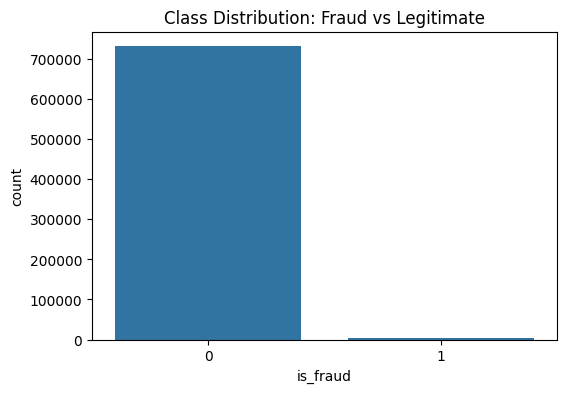

In [19]:
# Plot class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df_train)
plt.title("Class Distribution: Fraud vs Legitimate")
plt.show()

▶ **Class Imbalance Observation**

Fraudulent transactions account for less than 1% of total transactions, indicating a **severely imbalanced dataset**.

Implication:
- Accuracy is not a reliable evaluation metric
- Special techniques such as class weighting, resampling, and appropriate metrics (Recall, Precision, PR-AUC) are required


## Univariate Analysis

### Distribution over time

Transaction timing plays a critical role in fraud detection, as fraudulent activity often exhibits distinct temporal patterns such as:
- Transactions occurring during odd hours
- Increased activity during weekends
- Unusual bursts within short time windows

In this section, we analyze transaction distributions over time to identify such patterns and motivate time-based feature engineering.

In [20]:
# Extract time-based components
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['day'] = df_train['trans_date_trans_time'].dt.day
df_train['month'] = df_train['trans_date_trans_time'].dt.month
df_train['dayofweek'] = df_train['trans_date_trans_time'].dt.dayofweek

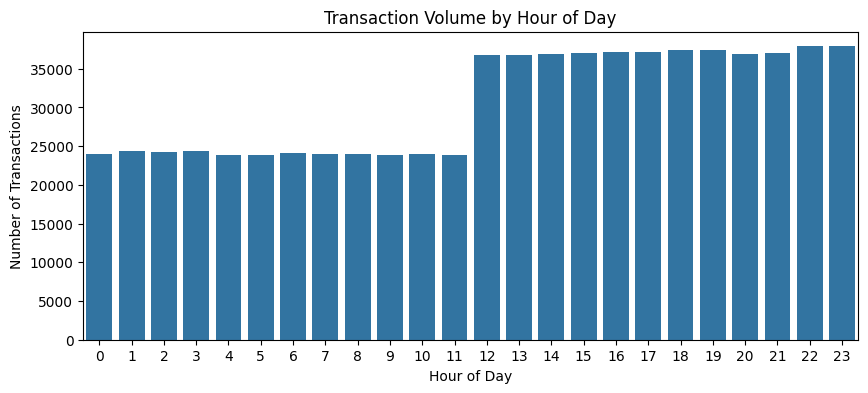

In [21]:
# Transactions per hour
transactions_per_hour = df_train['hour'].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.countplot(x='hour', data=df_train)
plt.title("Transaction Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

📊 **Transactions per Hour**

* Transaction volume follows a clear daily cycle, with higher activity during
typical business hours and lower activity late at night and morning hours.

* This baseline distribution is important, as fraud often deviates from normal transaction timing patterns.


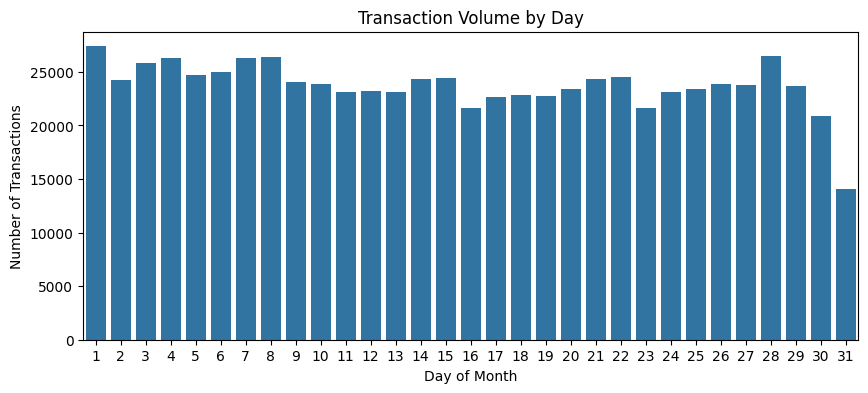

In [22]:
# Transactions per day
transactions_per_day = df_train['day'].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.countplot(x='day', data=df_train)
plt.title("Transaction Volume by Day")
plt.xlabel("Day of Month")
plt.ylabel("Number of Transactions")
plt.show()

📊 **Transactions per Day**

* This does not give much insight as transactions are almost in same range most of the days.


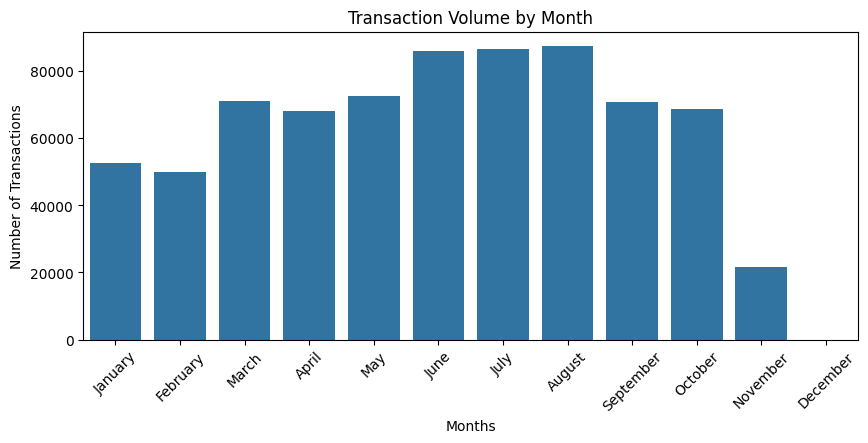

In [23]:
# Transactions per month
transactions_per_day = df_train['month'].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.countplot(x='month', data=df_train, order=range(1,13))
plt.title("Transaction Volume by Month")
plt.xlabel("Months")
plt.ylabel("Number of Transactions")
plt.xticks(
    ticks=range(12),
    labels=[calendar.month_name[i] for i in range(1,13)],
    rotation=45
)
plt.show()

📊 **Monthly Transaction Distribution Observation**

* Transactions are observed only from January to November in the training dataset.
December transactions are absent, as they might be present in the separate test dataset.

* This temporal separation reflects a realistic production scenario where models are trained on historical data and evaluated on future, unseen data.

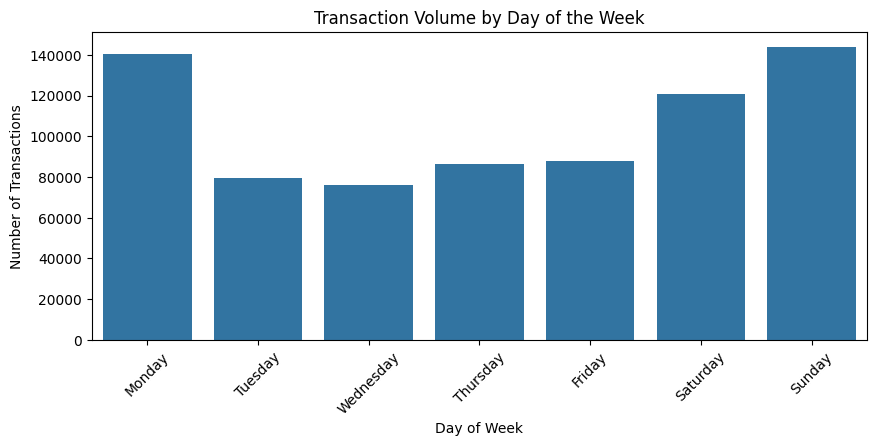

In [24]:
# Transactions per day of week
transactions_per_day = df_train['dayofweek'].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.countplot(x='dayofweek', data=df_train, order=range(7))
plt.title("Transaction Volume by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")
plt.xticks(
    ticks=range(7),
    labels=list(calendar.day_name),
    rotation=45
)
plt.show()

📊 **Day-of-Week Transaction Pattern**

* Transaction volumes peak during weekends (Saturday and Sunday) and remain relatively high on Mondays.

* This pattern is consistent with real-world consumer behavior, where discretionary spending typically increases over weekends, followed by carry-over or delayed transactions at the beginning of the workweek.


### Top Merchants by Transaction Volume

Merchants with high transaction volumes can exhibit distinct spending and fraud patterns.
Analyzing the most frequent merchants helps:
- Understand transaction concentration
- Identify merchants that dominate transaction activity
- Motivate merchant-level risk aggregation features

Due to the high cardinality of the `merchant` feature, analysis is limited to the top merchants by transaction count.

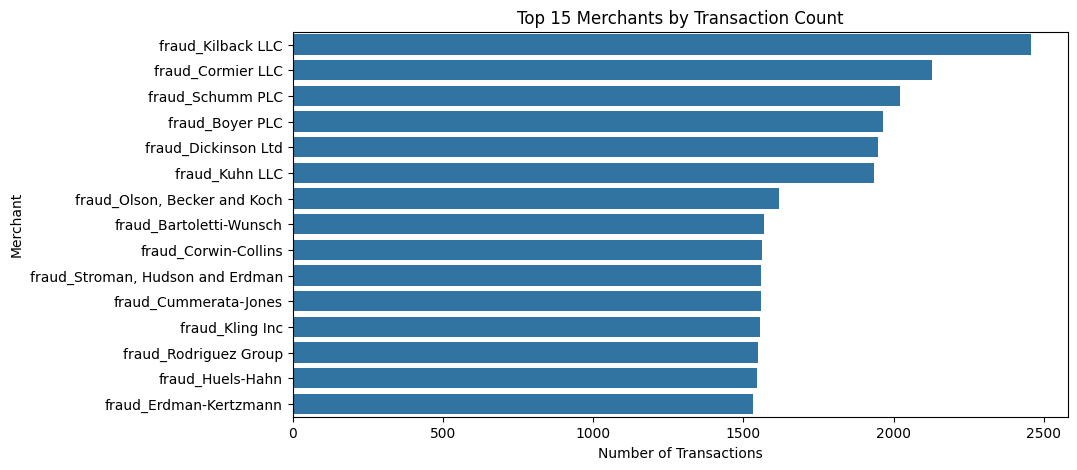

In [25]:
top_merchants = df_train['merchant'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_merchants.values,
    y=top_merchants.index
)
plt.title("Top 15 Merchants by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant")
plt.show()

📊 **Merchant-Level EDA Summary**

- High transaction volume does not necessarily correspond to higher fraud rates
- Merchant-level aggregation features will be more informative than raw merchant identifiers

This analysis informs subsequent feature engineering and model design decisions.


### Transaction Count per Category

Analyzing transaction counts across merchant categories helps understand spending concentration
and identifies categories with high transaction volumes.


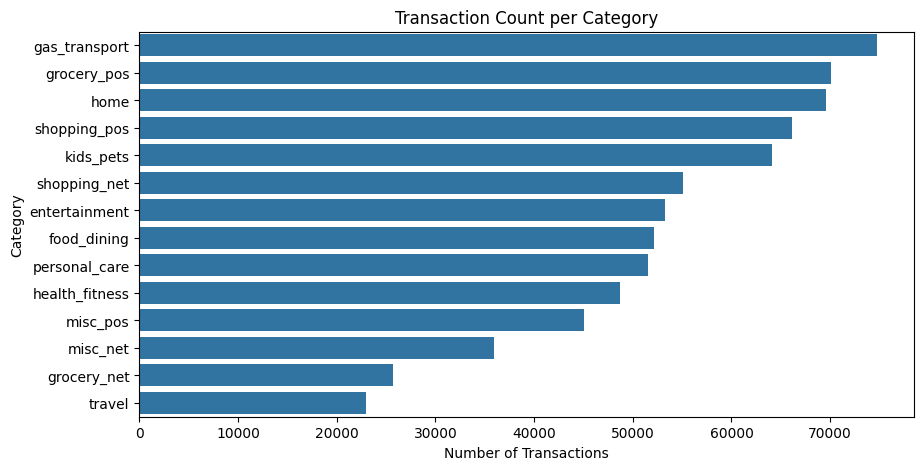

In [26]:
category_counts = (df_train['category'].value_counts())

plt.figure(figsize=(10,5))
sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)
plt.title("Transaction Count per Category")
plt.xlabel("Number of Transactions")
plt.ylabel("Category")
plt.show()

📊 **Category level Summary**

Transaction volumes vary  across categories, indicating that consumer spending
is concentrated in a few major merchant categories like
- gas_transport
- grocery_pos
- home
- shopping_pos
- kids_pets

### Transaction Amount Distribution

- Transaction amounts often exhibit heavy right skew due to occasional high-value purchases.
- A log-scale visualization is used to better capture the distribution.


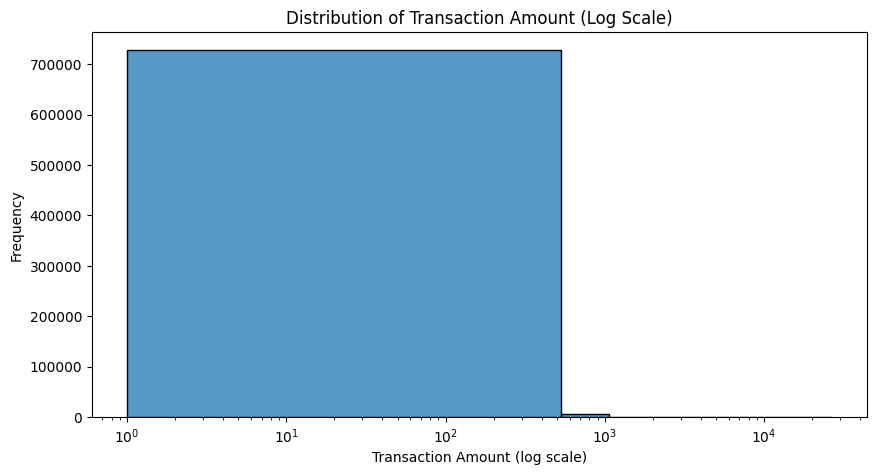

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df_train['amt'], bins=50)
plt.xscale('log')
plt.title("Distribution of Transaction Amount (Log Scale)")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Frequency")
plt.show()

### Gender Distribution

This analysis examines the distribution of transactions across genders.


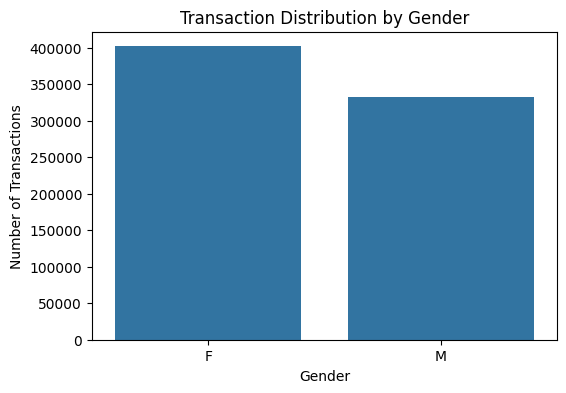

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df_train)
plt.title("Transaction Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.show()

📊 Transaction counts are relatively balanced across genders.
This observation is descriptive and does not imply any causal relationship with fraud.

### Transactions per State

State-level transaction analysis provides insight into geographic distribution of transactions.


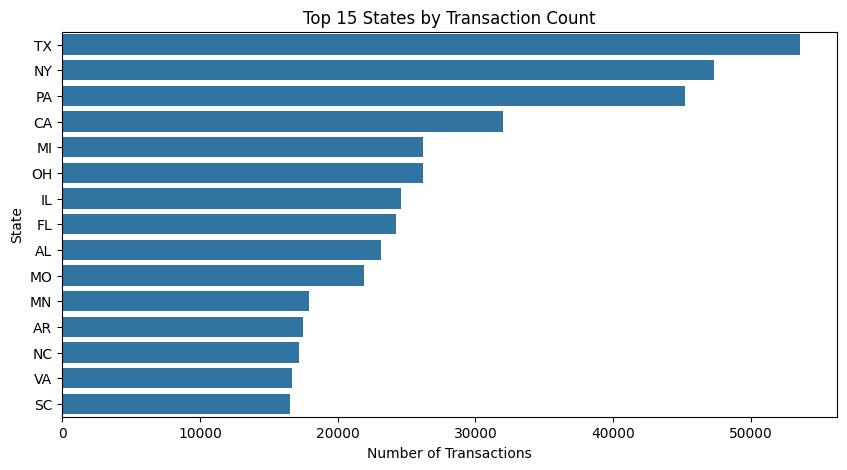

In [29]:
state_counts = (
    df_train['state']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=state_counts.values,
    y=state_counts.index
)
plt.title("Top 15 States by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("State")
plt.show()

📊 A small number of states account for a large proportion of transactions,
reflecting population density and economic activity concentration.


### Job Category Distribution

Due to the high cardinality of job titles, analysis is limited to the most frequent job categories.

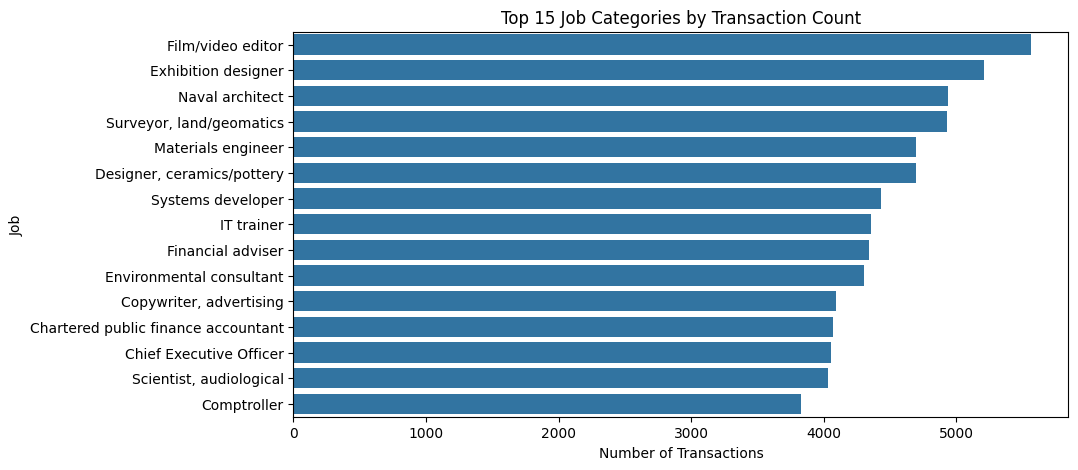

In [30]:
job_counts = (
    df_train['job']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=job_counts.values,
    y=job_counts.index
)
plt.title("Top 15 Job Categories by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Job")
plt.show()

📊 Transaction activity is concentrated among a limited set of job categories.
Direct use of job titles in modeling may be noisy; aggregation-based features may be more effective.

## Bivariate Analysis

* The objective of bivariate analysis is to examine how different features relate to fraudulent behavior.
* Instead of transaction volume, the focus is on **fraud rate**, which is more meaningful for highly imbalanced datasets.

* Fraud rate is defined as:
> Fraud Rate = (Number of Fraudulent Transactions) / (Total Transactions)


### Fraud Rate by Hour of Day

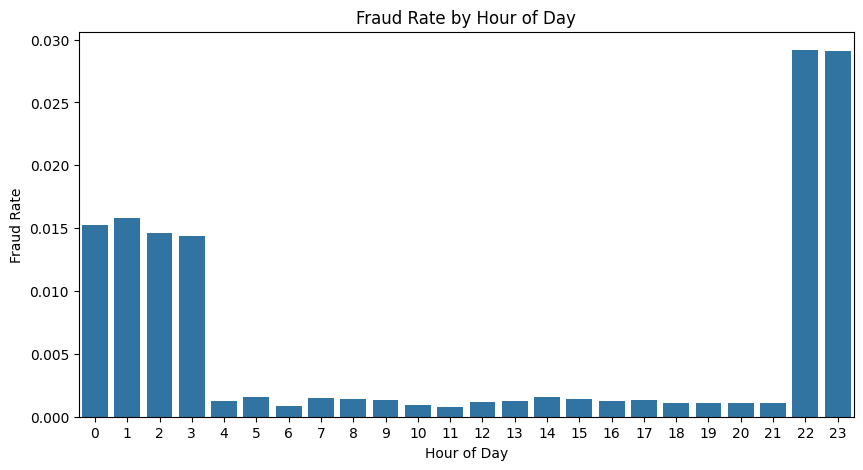

In [31]:
fraud_by_hour = (
    df_train
    .groupby('hour')['is_fraud']
    .mean()
)

plt.figure(figsize=(10,5))
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values)
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

📊 Fraud rates are more during non-business hours (mid-night), even though transaction volume is lower.
This suggests that time-of-day is a strong behavioral signal for fraud detection.


### Fraud Rate by Day of Week

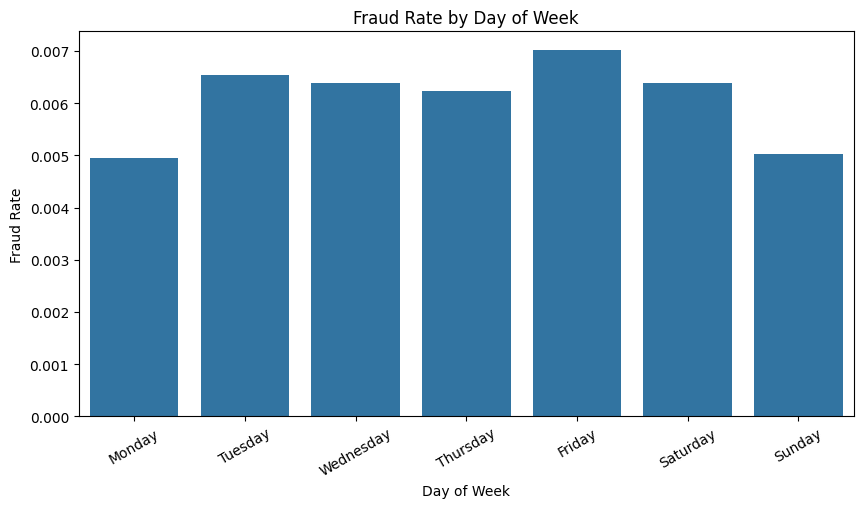

In [32]:
fraud_by_day = (
    df_train
    .groupby('dayofweek')['is_fraud']
    .mean()
)

plt.figure(figsize=(10,5))
sns.barplot(x=fraud_by_day.index, y=fraud_by_day.values)
plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate")
plt.xticks(
    ticks=range(7),
    labels=list(calendar.day_name),
    rotation=30)
plt.show()

📊 The chart shows variation in fraud rates across different days of the week.

Key observations:
- Fraud rates are **lowest on Monday and Sunday**, indicating relatively lower fraud risk at the start and end of the week.
- Fraud rates gradually increase from Tuesday through Thursday.
- **Friday exhibits the highest fraud rate**, suggesting elevated risk toward the end of the workweek.
- Weekend fraud rates (Saturday and Sunday) are mixed: Saturday remains relatively high, while Sunday drops closer to weekday lows.

Interpretation:
- The increase in fraud risk toward the end of the week may be associated with higher transaction activity, delayed monitoring, or opportunistic fraudulent behavior.
- Lower fraud rates on Sunday may reflect reduced transaction volume or more conservative spending patterns.
- Day-of-week is a meaningful temporal feature and should be included in the model.


**Further analysis will explore interactions between day-of-week and hour-of-day to capture more granular temporal fraud patterns.**


### Fraud Rate by Merchant

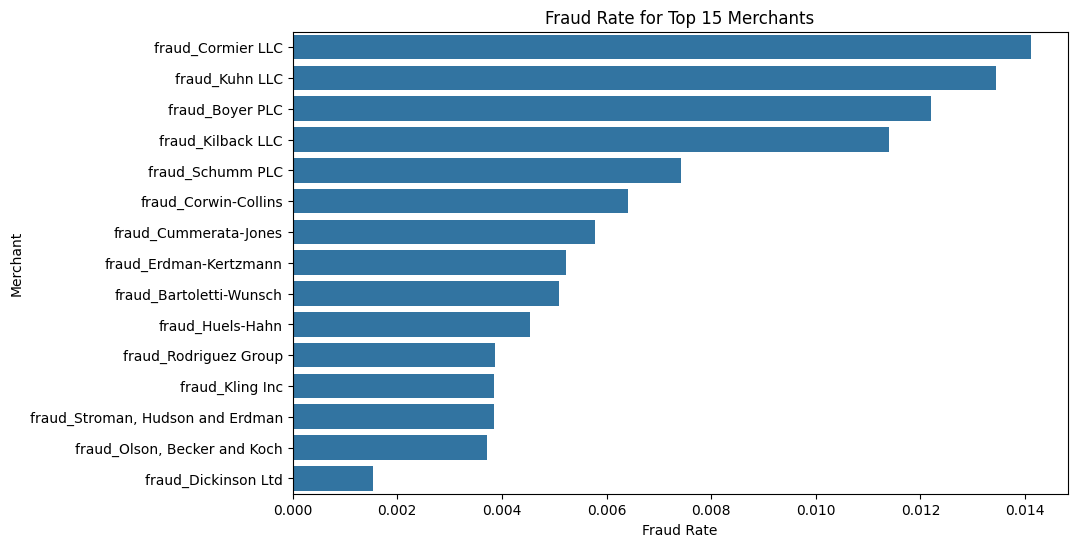

In [33]:
top_merchants = df_train['merchant'].value_counts().head(15).index

merchant_fraud = (
    df_train[df_train['merchant'].isin(top_merchants)]
    .groupby('merchant')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=merchant_fraud.values,
    y=merchant_fraud.index
)
plt.title("Fraud Rate for Top 15 Merchants")
plt.xlabel("Fraud Rate")
plt.ylabel("Merchant")
plt.show()

📊 The chart presents fraud rates for the top 15 merchants (selected based on transaction volume), revealing substantial variation in fraud risk at the merchant level.

Key observations:
- A small subset of merchants exhibits **notably higher fraud rates** compared to others.
- Several merchants show consistently elevated fraud risk despite not necessarily having the highest transaction volumes.
- Fraud rates vary widely even among the top merchants, indicating that merchant identity alone does not uniformly determine fraud risk.


### Fraud Rate by Category

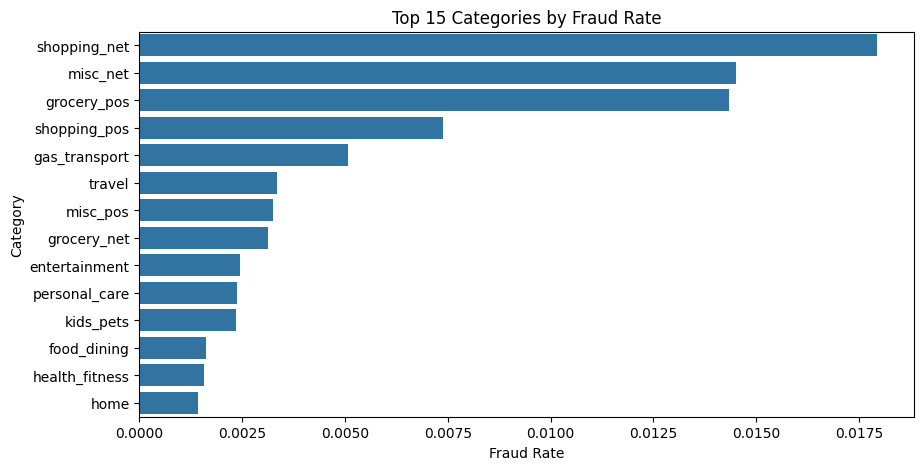

In [34]:
category_fraud = (
    df_train
    .groupby('category')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=category_fraud.head(15).values,
    y=category_fraud.head(15).index
)
plt.title("Top 15 Categories by Fraud Rate")
plt.xlabel("Fraud Rate")
plt.ylabel("Category")
plt.show()

📊 The chart displays the fraud rate across the top 15 merchant categories, highlighting significant variation in fraud risk by transaction type.

Key observations:
- **Online-based categories** such as `shopping_net` and `misc_net` exhibit the **highest fraud rates** among all categories.
- Point-of-sale categories like `grocery_pos` and `shopping_pos` show comparatively lower fraud rates than their online counterparts.
- Essential or routine spending categories such as `home`, `health_fitness`, and `food_dining` show relatively lower fraud rates.

### Transaction Amount vs Fraud

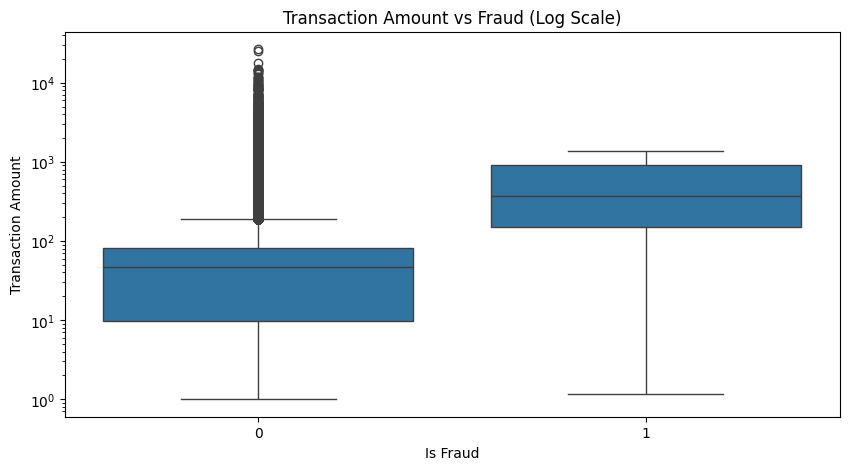

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(x='is_fraud', y='amt', data=df_train)
plt.yscale('log')
plt.title("Transaction Amount vs Fraud (Log Scale)")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Amount")
plt.show()

📊 The boxplot compares the distribution of transaction amounts for fraudulent and non-fraudulent transactions using a logarithmic scale.

Key observations:
- Fraudulent transactions (`is_fraud = 1`) tend to have **significantly higher transaction amounts** compared to legitimate transactions.
- The median transaction amount for fraud cases is substantially higher than that of non-fraud cases.
- Non-fraudulent transactions are heavily concentrated at lower amounts, with a long right tail representing occasional high-value legitimate purchases.

Implications for modeling:
- Transaction amount is a strong predictive feature for fraud detection.

### Fraud Rate by Gender

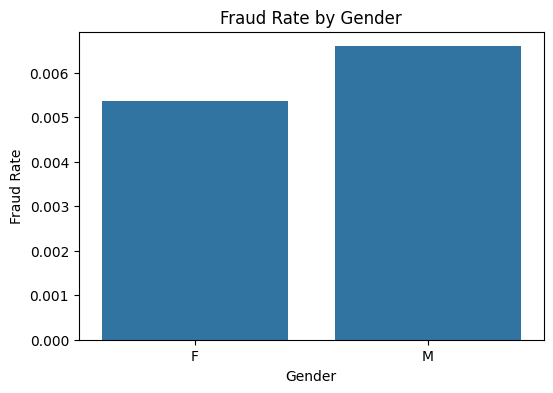

In [36]:
fraud_by_gender = (
    df_train
    .groupby('gender')['is_fraud']
    .mean()
)
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_by_gender.index, y=fraud_by_gender.values)
plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")
plt.show()

📊 The chart compares fraud rates across genders and shows a modest difference between male and female cardholders.

Key observations:
- The fraud rate for male cardholders is slightly higher than that for female cardholders.
- The overall difference in fraud rates across genders is relatively small compared to other factors such as transaction amount, time, or merchant category.

Interpretation:
- Gender alone does not appear to be a strong standalone predictor of fraud.
- Observed differences may reflect indirect behavioral patterns or usage contexts rather than any causal relationship.
- Gender can be retained as a supporting feature but should not be heavily weighted in isolation.
- It is more effective when combined with transactional, temporal, and behavioral features.


### Fraud Rate by State

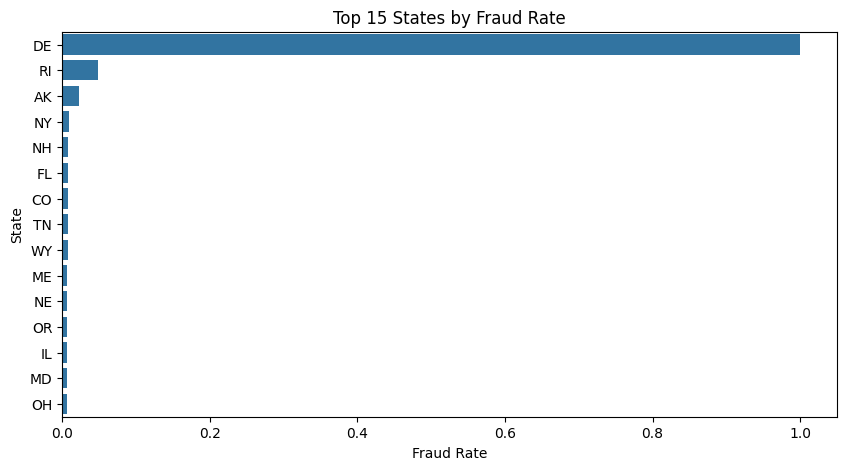

In [37]:
state_fraud = (
    df_train
    .groupby('state')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=state_fraud.head(15).values,
    y=state_fraud.head(15).index
)
plt.title("Top 15 States by Fraud Rate")
plt.xlabel("Fraud Rate")
plt.ylabel("State")
plt.show()

📊 The chart shows the fraud rate across the top 15 states, highlighting significant variation in fraud risk by geographic location.

Key observations:
- One state (DE) exhibits an **exceptionally high fraud rate** compared to all other states.
- Most other states show relatively low and closely clustered fraud rates.
- The distribution is highly skewed, with a single state dominating the scale.


### Fraud Rate by Job

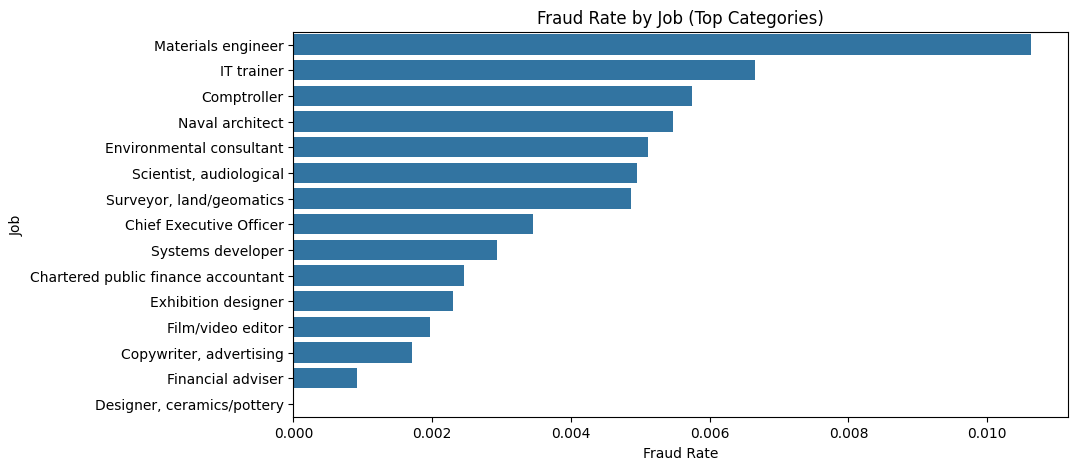

In [38]:
top_jobs = df_train['job'].value_counts().head(15).index

job_fraud = (
    df_train[df_train['job'].isin(top_jobs)]
    .groupby('job')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=job_fraud.values,
    y=job_fraud.index
)
plt.title("Fraud Rate by Job (Top Categories)")
plt.xlabel("Fraud Rate")
plt.ylabel("Job")
plt.show()

📊 The chart shows fraud rates across the top job categories, highlighting variation in fraud risk by occupation.

Key observations:
- Fraud rates vary noticeably across job categories, with some occupations showing higher observed fraud rates than others.
- The distribution is uneven, with a small number of job categories appearing at the higher end of the fraud rate scale.

## Advanced Behavioral Analysis

### Transaction Volume vs Fraud Risk

High transaction volume does not necessarily imply higher fraud risk.
In this section, transaction volume is compared against fraud rate to highlight categories
where fraud risk is disproportionately high relative to usage.


In [39]:
category_summary = (
    df_train
    .groupby('category')
    .agg(
        transaction_count=('is_fraud', 'count'),
        fraud_rate=('is_fraud', 'mean')
    )
    .sort_values('transaction_count', ascending=False)
)

category_summary.head(10)

,transaction_count,fraud_rate
category,,
gas_transport,74779,0.005082
grocery_pos,70069,0.014343
home,69551,0.001438
shopping_pos,66127,0.007380
kids_pets,64101,0.002340
shopping_net,55120,0.017943
entertainment,53214,0.002443
food_dining,52124,0.001631
personal_care,51535,0.002367


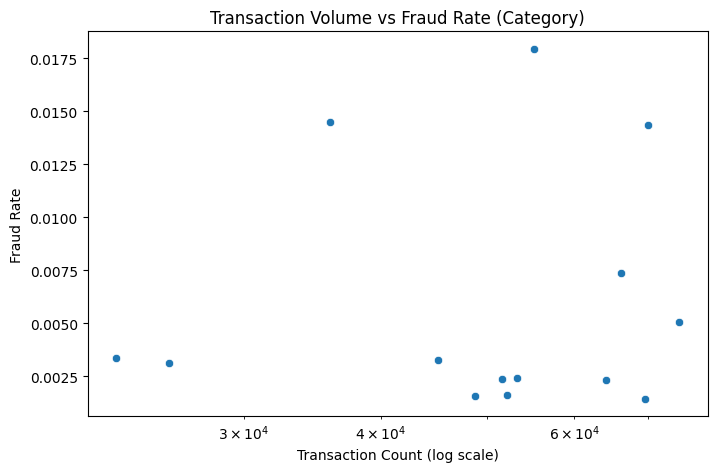

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=category_summary,
    x='transaction_count',
    y='fraud_rate'
)
plt.xscale('log')
plt.title("Transaction Volume vs Fraud Rate (Category)")
plt.xlabel("Transaction Count (log scale)")
plt.ylabel("Fraud Rate")
plt.show()

🏁 The scatter plot compares transaction volume (log scale) against fraud rate across merchant categories.

Key observations:
- There is **no clear linear relationship** between transaction volume and fraud rate.
- Some categories with **moderate transaction volume** exhibit **disproportionately high fraud rates**.
- Conversely, several high-volume categories show **relatively low fraud rates**, indicating stable and well-controlled transaction behavior.
- Fraud risk varies independently of transaction frequency.
- **High Volume ≠ High Fraud rRsk**

### Fraud Rate by Transaction Amount Buckets

To capture behavior, transaction amounts are grouped into discrete buckets and fraud rate is analyzed per bucket.


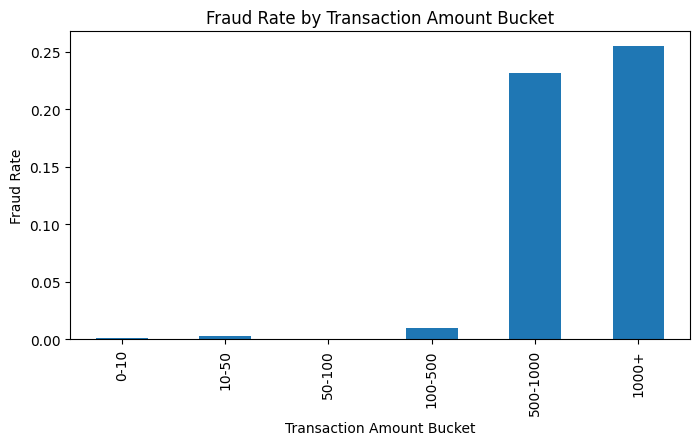

In [41]:
# Define amount bins
bins = [0, 10, 50, 100, 500, 1000, df_train['amt'].max()]
labels = ['0-10', '10-50', '50-100', '100-500', '500-1000', '1000+']

df_train['amt_bucket'] = pd.cut(
    df_train['amt'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

amount_bucket_fraud = (
    df_train
    .groupby('amt_bucket')['is_fraud']
    .mean()
)

plt.figure(figsize=(8,4))
amount_bucket_fraud.plot(kind='bar')
plt.title("Fraud Rate by Transaction Amount Bucket")
plt.xlabel("Transaction Amount Bucket")
plt.ylabel("Fraud Rate")
plt.show()

📊 The chart illustrates fraud rates across different transaction amount buckets, revealing a strong non-linear relationship between transaction amount and fraud risk.

Key observations:
- Fraud rates are **extremely low** for low-value transactions (below 100).
- A noticeable increase in fraud rate appears in the **100–500** amount range.
- Fraud risk increases **sharply and disproportionately** for high-value transactions:
  - Transactions in the **500–1000** range show a substantial rise in fraud rate.
  - Transactions above **1000** exhibit the **highest fraud rate**, exceeding 25%.

Interpretation:
- Fraudsters tend to target higher-value transactions to maximize financial gain before detection.
- Low-value transactions are less attractive for fraud and may also be more common, diluting fraud rates.
- Transaction amount is a **critical predictive feature** for fraud detection.

### Fraud Rate Hour vs Day of Week

Fraud risk may vary jointly across time-of-day and day-of-week.
This heatmap visualizes fraud rate across these two temporal dimensions.


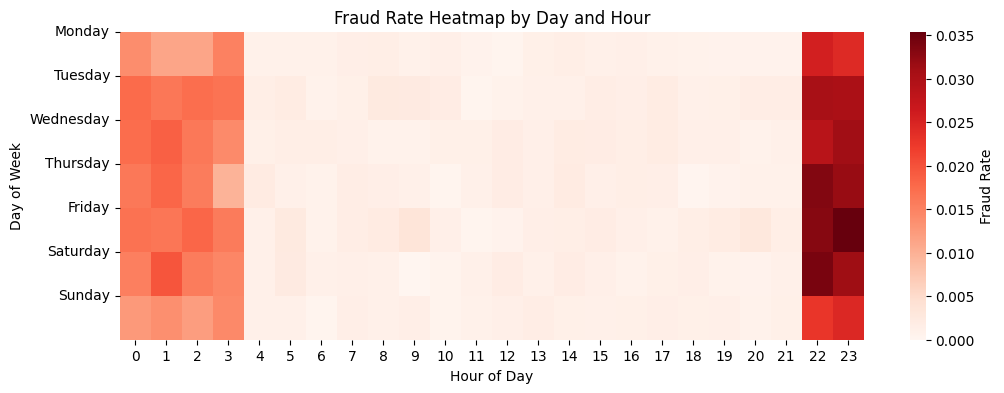

In [42]:
heatmap_data = (
    df_train
    .groupby(['dayofweek', 'hour'])['is_fraud']
    .mean()
    .unstack()
)

heatmap_data = heatmap_data.reindex(range(7))

plt.figure(figsize=(12,4))
sns.heatmap(
    heatmap_data,
    cmap='Reds',
    cbar_kws={'label': 'Fraud Rate'}
)
plt.title("Fraud Rate Heatmap by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
# Replace numeric ticks with names
plt.yticks(
    ticks=range(7),
    labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    rotation=0
    )
plt.show()

🏁 The heatmap illustrates fraud rates across the joint dimensions of hour of day and day of week, revealing clear temporal interaction patterns.

Key observations:
- Fraud rates are **consistently elevated during late-night hours**, particularly between **22:00 and 23:00**, across almost all days of the week.
- Early morning hours (00:00–03:00) also show moderately higher fraud risk compared to daytime hours.
- Fraud rates are **lowest during standard business hours** (approximately 05:00–18:00), indicating relatively safer transaction periods.
- Weekend days (Friday night through Saturday) exhibit slightly higher late-night fraud intensity compared to weekdays.

### Customer-Level Transaction Frequency

Fraud is often associated with abnormal customer behavior patterns.
This section examines transaction frequency at the cardholder level.


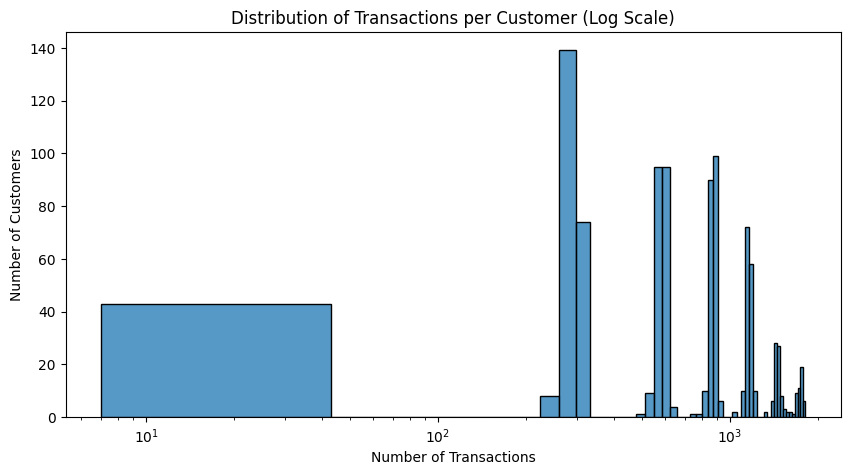

In [43]:
# Transactions per customer
tx_per_customer = (
    df_train
    .groupby('cc_num')
    .size()
)

plt.figure(figsize=(10,5))
sns.histplot(tx_per_customer, bins=50)
plt.xscale('log')
plt.title("Distribution of Transactions per Customer (Log Scale)")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.show()

📊 The histogram shows the distribution of the number of transactions per customer on a logarithmic scale, highlighting significant variation in customer transaction behavior.

Key observations:
- The distribution is **highly right-skewed**, indicating that most customers perform a relatively small number of transactions.
- A small subset of customers exhibits **very high transaction counts**, spanning several orders of magnitude higher than the average customer.
- The log-scale visualization reveals long-tail behavior that would be difficult to observe on a linear scale.

## Data Skewness Analysis

In [44]:
#checking numerical columns for skewness
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

skewness = df_train[numeric_cols].skew().sort_values(ascending=False)
skewness

amt           37.783837
city_pop       5.599009
unix_time     -0.129369
merch_lat     -0.182177
lat           -0.186612
merch_long    -1.144041
long          -1.147237
dtype: float64

- From above we can see that `amt` is extremly right skew (37.78), and it needs transformation.
- Also `city_pop` is highly right skewed (5.60), this as well need transformation as this can impact linear models.
- Feature `is_fraud` is also showing right skewnesss (12.88), but it is binary variable where imbalance is expected and Skewness metric is meaningless here.

### Skewness for amount

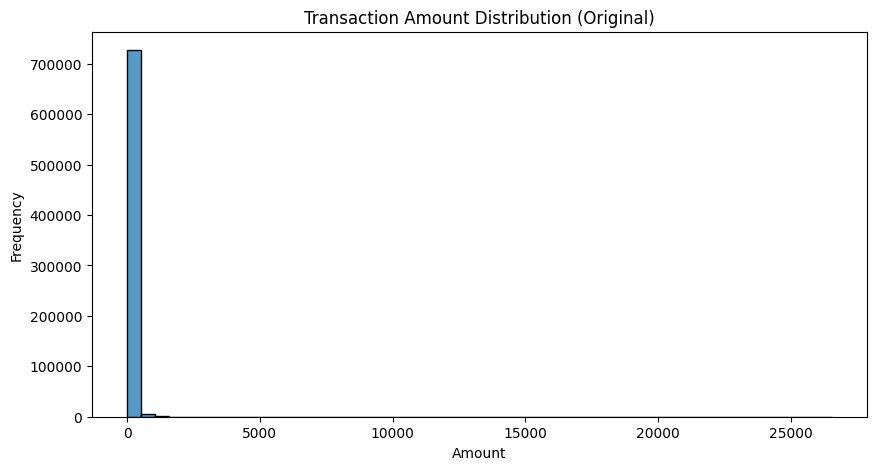

In [45]:
# Visualizing Skewness for amount
plt.figure(figsize=(10,5))
sns.histplot(df_train['amt'], bins=50)
plt.title("Transaction Amount Distribution (Original)")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

The original transaction amount distribution exhibits extreme right skewness.

Key observations:
- The majority of transactions are concentrated at very low amounts.
- A small number of transactions extend to very high values, creating a long right tail.
- The distribution is heavily compressed near zero, making it difficult to observe meaningful variation on a linear scale.

Interpretation:
- Such extreme skewness can negatively impact linear and distance-based models.
- Large outliers dominate the scale and distort feature representation.
- Fraud detection datasets commonly exhibit this behavior due to occasional high-value transactions.

Implications:
- Logarithmic transformation is necessary to stabilize variance and improve interpretability.
- Skewness mitigation will improve model robustness without removing legitimate fraud signals.


### Skewness for city_pop

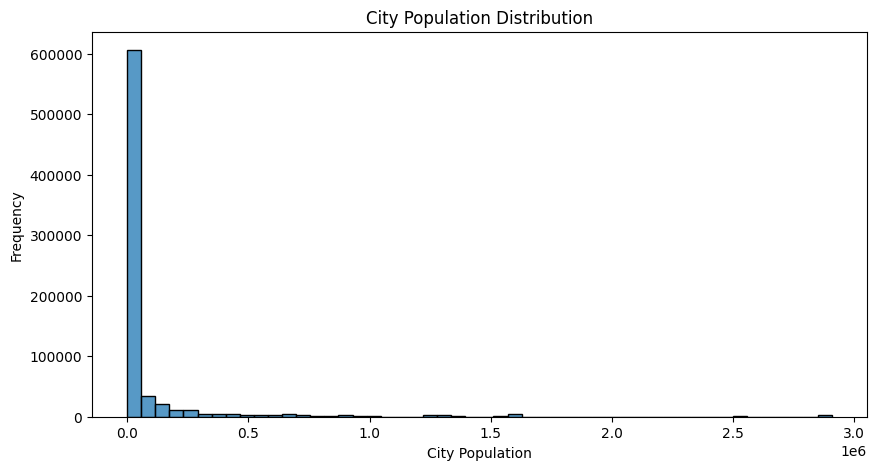

In [46]:
# Visualizing Skewness for city_pop
plt.figure(figsize=(10,5))
sns.histplot(df_train['city_pop'], bins=50)
plt.title("City Population Distribution")
plt.xlabel("City Population")
plt.ylabel("Frequency")
plt.show()

The distribution of city population exhibits strong right skewness.

Key observations:
- The majority of transactions originate from cities with relatively small populations.
- A small number of large metropolitan cities contribute extremely high population values, creating a long right tail.
- The distribution is heavily concentrated near lower population values, with outliers extending into the millions.

Interpretation:
- Population distribution naturally follows a long-tail pattern, as large cities are rare compared to small towns.
- Highly skewed demographic features can distort model behavior, particularly in linear and distance-based models.

Implications:
- Logarithmic transformation is appropriate to stabilize variance and reduce the dominance of extreme population values.
- Population-based features may capture urban vs rural behavioral differences relevant to fraud detection.


### Skewness Handling

- Skewness analysis revealed that transaction amount and city population were highly right-skewed.
- Logarithmic transformation was applied to stabilize variance and improve model robustness, particularly for linear and distance-based algorithms.
- Other numeric features such as geographic coordinates and temporal variables did not require transformation.


In [47]:
df_train['log_amt'] = np.log1p(df_train['amt'])
df_train['log_city_pop'] = np.log1p(df_train['city_pop'])

In [48]:
df_train[['amt','log_amt','city_pop','log_city_pop']].skew()

amt             37.783837
log_amt         -0.297285
city_pop         5.599009
log_city_pop     0.605958
dtype: float64

Logarithmic transformation significantly reduced skewness in key numeric features:

- Transaction amount skew reduced from 37.78 to -0.30
- City population skew reduced from 5.60 to 0.61

The transformed features exhibit substantially improved symmetry,
making them more suitable for linear and distance-based models while
retaining important fraud-related information.


In [49]:
# For clean feature set
df_train.drop(columns=['amt','city_pop'], inplace=True)

# 4 - Train/Validation Data Splitting

## Prepare Features and Target

In [50]:
X = df_train.drop(columns=['is_fraud'])
y = df_train['is_fraud']

print("Overall Fraud Rate:", y.mean())

Overall Fraud Rate: 0.005921152883296689


## Splitting the Data (80% Train & 20% Validation)

- A stratified holdout split (80/20) is performed to create a final unseen test set.
- Stratification ensures that the minority fraud class is proportionally represented.


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Development Fraud Rate:", y_train.mean())
print("Test Fraud Rate:", y_test.mean())

Development Fraud Rate: 0.005921839205568774
Test Fraud Rate: 0.005918407608215022


# 5 - Feature Engineering

## Time-Based Feature

In [52]:
# Weeekend flag
X_train['is_weekend'] = X_train['dayofweek'].isin([5, 6]).astype(int)
X_test['is_weekend'] = X_test['dayofweek'].isin([5, 6]).astype(int)

# Night transaction flag
X_train['is_night'] = X_train['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)
X_test['is_night'] = X_test['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)

# Late evening flag
X_train['is_late_evening'] = X_train['hour'].isin([20, 21, 22, 23]).astype(int)
X_test['is_late_evening'] = X_test['hour'].isin([20, 21, 22, 23]).astype(int)

## Age Feature

In [53]:
# Calculate age
X_train['age'] = (
    X_train['trans_date_trans_time'].dt.year - X_train['dob'].dt.year
)
X_test['age'] = (
    X_test['trans_date_trans_time'].dt.year - X_test['dob'].dt.year
)

# Cap unrealistic ages
X_train['age'] = X_train['age'].clip(18, 100)
X_test['age'] = X_test['age'].clip(18, 100)

Age values were capped between 18 and 100 to remove unrealistic outliers
while preserving dataset size. This prevents extreme values from distorting
model training without discarding potentially useful records.


## Amount-Based Features


We have already created `log_amt` feature, now we will add Amount Relative to Customer Average.

In [54]:
# Customer average transaction amount
customer_avg_amt_train = (
    X_train
    .groupby('cc_num')['log_amt']
    .transform('mean')
)
customer_avg_amt_test = (
    X_test
    .groupby('cc_num')['log_amt']
    .transform('mean')
)

X_train['amt_vs_customer_avg'] = (
    X_train['log_amt'] - customer_avg_amt_train
)
X_test['amt_vs_customer_avg'] = (
    X_test['log_amt'] - customer_avg_amt_test
)

This captures:

> Is this transaction unusually large for this customer?

Very strong fraud signal.

## Velocity-Based Features

Velocity-Based Features are very important as Fraud often occurs in bursts.


In [55]:
# Transaction per card

X_train['tx_count_per_card'] = (
    X_train
    .groupby('cc_num')['cc_num']
    .transform('count')
)
X_test['tx_count_per_card'] = (
    X_test
    .groupby('cc_num')['cc_num']
    .transform('count')
)

In [56]:
# Transactions per Card per Day

X_train['tx_per_day'] = (
    X_train
    .groupby(['cc_num', X_train['trans_date_trans_time'].dt.date])
    ['cc_num']
    .transform('count')
)
X_test['tx_per_day'] = (
    X_test
    .groupby(['cc_num', X_test['trans_date_trans_time'].dt.date])
    ['cc_num']
    .transform('count')
)

In [57]:
# High Activity Flag

X_train['high_activity_flag'] = (
    X_train['tx_per_day'] > 5
).astype(int)
X_test['high_activity_flag'] = (
    X_test['tx_per_day'] > 5
).astype(int)

## Geographic Features

- We have `lat`, `long`, `merch_lat`, `merch_long` features but those are raw coordinates.
- Instead of raw coordinates, we can create **Distance Between Customer & Merchant**.

In [58]:
def calculate_distance(row):
    return geodesic(
        (row['lat'], row['long']),
        (row['merch_lat'], row['merch_long'])
    ).km

X_train['distance_km'] = X_train.apply(calculate_distance, axis=1)
X_test['distance_km'] = X_test.apply(calculate_distance, axis=1)

## Risk Encoding

We will not be doing one-hot encoding to high-cardinality features like merchant, category, state etc. Instead, we compute historical fraud rates.

In [59]:
X_train['is_fraud'] = y_train
X_test['is_fraud'] = y_test

In [60]:
# Category Fraud Risk

category_risk_train = (
    X_train
    .groupby('category')['is_fraud']
    .mean()
)
category_risk_test = (
    X_test
    .groupby('category')['is_fraud']
    .mean()
)

X_train['category_risk'] = X_train['category'].map(category_risk_train)
X_test['category_risk'] = X_test['category'].map(category_risk_test)

In [61]:
# Merchant Fraud Risk

merchant_risk_train = (
    X_train
    .groupby('merchant')['is_fraud']
    .mean()
)
merchant_risk_test = (
    X_test
    .groupby('merchant')['is_fraud']
    .mean()
)

X_train['merchant_risk'] = X_train['merchant'].map(merchant_risk_train)
X_test['merchant_risk'] = X_test['merchant'].map(merchant_risk_test)

In [62]:
# State Fraud Risk

state_risk_train = (
    X_train
    .groupby('state')['is_fraud']
    .mean()
)
state_risk_test = (
    X_test
    .groupby('state')['is_fraud']
    .mean()
)

X_train['state_risk'] = X_train['state'].map(state_risk_train)
X_test['state_risk'] = X_test['state'].map(state_risk_test)

In [63]:
# City Fraud Risk

city_risk_train = (
    X_train
    .groupby('city')['is_fraud']
    .mean()
)
city_risk_test = (
    X_test
    .groupby('city')['is_fraud']
    .mean()
)

X_train['city_risk'] = X_train['city'].map(city_risk_train)
X_test['city_risk'] = X_test['city'].map(city_risk_test)

In [64]:
# Job Fraud Risk

job_risk_train = (
    X_train
    .groupby('job')['is_fraud']
    .mean()
)
job_risk_test = (
    X_test
    .groupby('job')['is_fraud']
    .mean()
)

X_train['job_risk'] = X_train['job'].map(job_risk_train)
X_test['job_risk'] = X_test['job'].map(job_risk_test)

Based on insights from exploratory data analysis, the following features were engineered:

- Temporal interaction features (hour, weekend, night flags)
- Age derived from date of birth
- Log-transformed transaction amount
- Customer-level behavioral features (transaction velocity)
- Risk-based encodings for category, merchant, state, city and job

These features capture transactional, behavioral, and contextual fraud signals
while avoiding high-cardinality raw categorical variables.

## Clean Final Feature Set

We need to drop below features as these features may cause:
* Leakage
* Redundancy
* Overfitting
* High cardinality noise

In [65]:
cols_to_drop = [
    'trans_date_trans_time',  # We have derived multiple features to reflect this such as hour, day, month, dayofweek, is_weekend, is_night, is_late_evening
    'unix_time',              # it is same as transaction time in unix time format
    'trans_num',              # unique transaction ID which will not help in fraud detection
    'first',                  # Personally Identifiable Information which will not help in fraud detection
    'last',                   # Personally Identifiable Information which will not help in fraud detection
    'street',                 # Personally Identifiable Information which will not help in fraud detection
    'zip',                    # high-cardinality noise
    'merchant',               # replaced with merchant_risk
    'category',               # replaced with category_risk
    'state',                  # replaced with state_risk
    'city',                   # replaced with city_risk
    'job',                    # replaced with job_risk
    'dob',                    # replaced by age
    'cc_num',                 # high-cardinality noise, Identifier (not behavioral)
    'amt_bucket',             # replaced with log_amt, amt_vs_customer_avg
    'lat',                    # replaced with distance_km
    'long',                   # replaced with distance_km
    'merch_lat',              # replaced with distance_km
    'merch_long'              # replaced with distance_km
]

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

# Drop 'is_fraud' as we have added this column temporary
X_train.drop(columns=['is_fraud'], inplace=True)
X_test.drop(columns=['is_fraud'], inplace=True)

## Binary Encoding Gender Feature

In [66]:
X_train['gender'] = X_train['gender'].map({'M': 1, 'F': 0})
X_test['gender'] = X_test['gender'].map({'M': 1, 'F': 0})

The gender feature was binary encoded (M = 1, F = 0) to convert
categorical values into numeric form suitable for modeling.
Since gender has only two categories, simple binary encoding
is sufficient and avoids unnecessary dimensional expansion.


## Feature Correlation

In [67]:
# correlation matrix
corr = X_train.corr()
corr

,gender,hour,day,month,dayofweek,log_amt,log_city_pop,is_weekend,is_night,is_late_evening,age,amt_vs_customer_avg,tx_count_per_card,tx_per_day,high_activity_flag,distance_km,category_risk,merchant_risk,state_risk,city_risk,job_risk
gender,1.000000e+00,-0.036758,-0.002062,-1.283470e-05,0.000016,0.036385,3.912728e-02,-0.003352,0.008473,-0.018307,5.373531e-03,4.423733e-17,-2.149022e-01,-0.112853,-0.095123,-9.215191e-04,-0.012132,-0.010696,6.816937e-03,2.043701e-02,2.438810e-02
hour,-3.675820e-02,1.000000,0.002053,-2.317422e-03,-0.000098,-0.140278,3.242779e-02,0.000136,-0.169083,0.646573,-1.707120e-01,-1.368542e-01,1.068074e-01,0.060854,0.049271,9.016670e-04,-0.386261,-0.347235,-4.501624e-03,-2.188062e-03,-6.413416e-03
day,-2.061616e-03,0.002053,1.000000,-5.741580e-02,0.009826,0.000223,2.805192e-04,0.003360,0.000010,0.001974,-6.469170e-04,2.008955e-04,9.841523e-04,0.011979,0.010751,4.410239e-04,-0.000335,-0.001365,5.032414e-03,5.097492e-03,-1.066501e-03
month,-1.283470e-05,-0.002317,-0.057416,1.000000e+00,0.048319,-0.001768,-2.154685e-03,0.046623,0.001327,-0.000143,9.135068e-04,-1.335338e-03,-6.768697e-04,0.093535,0.070965,-7.063546e-07,-0.000892,-0.000444,-2.274154e-03,-1.256822e-02,5.297957e-04
dayofweek,1.625244e-05,-0.000098,0.009826,4.831889e-02,1.000000,-0.000497,2.585608e-03,0.824568,-0.001145,-0.000459,-1.301737e-02,7.811756e-04,5.524260e-03,0.083069,0.062382,-4.796636e-04,0.002878,0.004110,8.992642e-04,-3.088478e-03,2.837880e-04
log_amt,3.638512e-02,-0.140278,0.000223,-1.768360e-03,-0.000497,1.000000,-1.568549e-02,-0.002435,0.046969,-0.057931,-3.002853e-02,9.641467e-01,-2.435927e-02,-0.007575,-0.007337,-1.127890e-03,0.001783,0.002727,7.012954e-03,4.036718e-02,2.892354e-02
log_city_pop,3.912728e-02,0.032428,0.000281,-2.154685e-03,0.002586,-0.015685,1.000000e+00,0.007072,-0.007755,0.013741,-1.547284e-01,3.756277e-17,2.114930e-02,0.021965,0.025146,2.011626e-02,-0.006705,-0.006788,2.166738e-02,1.051843e-02,1.720371e-03
is_weekend,-3.352099e-03,0.000136,0.003360,4.662253e-02,0.824568,-0.002435,7.072019e-03,1.000000,-0.001727,-0.000923,-1.331508e-02,-4.002195e-04,4.921968e-03,0.197306,0.158602,-2.867008e-04,0.001334,0.001799,1.969200e-03,-2.858941e-03,-1.093533e-04
is_night,8.473412e-03,-0.169083,0.000010,1.327293e-03,-0.001145,0.046969,-7.755076e-03,-0.001727,1.000000,0.323536,3.795871e-02,4.454460e-02,-3.125735e-02,-0.011970,-0.009286,2.816148e-03,0.094986,0.086854,6.329382e-03,3.631514e-02,2.417619e-02
is_late_evening,-1.830749e-02,0.646573,0.001974,-1.431585e-04,-0.000459,-0.057931,1.374069e-02,-0.000923,0.323536,1.000000,-7.871976e-02,-5.699690e-02,4.632055e-02,0.029067,0.024351,1.416824e-03,-0.178191,-0.159684,6.418890e-04,1.670339e-02,8.120843e-03


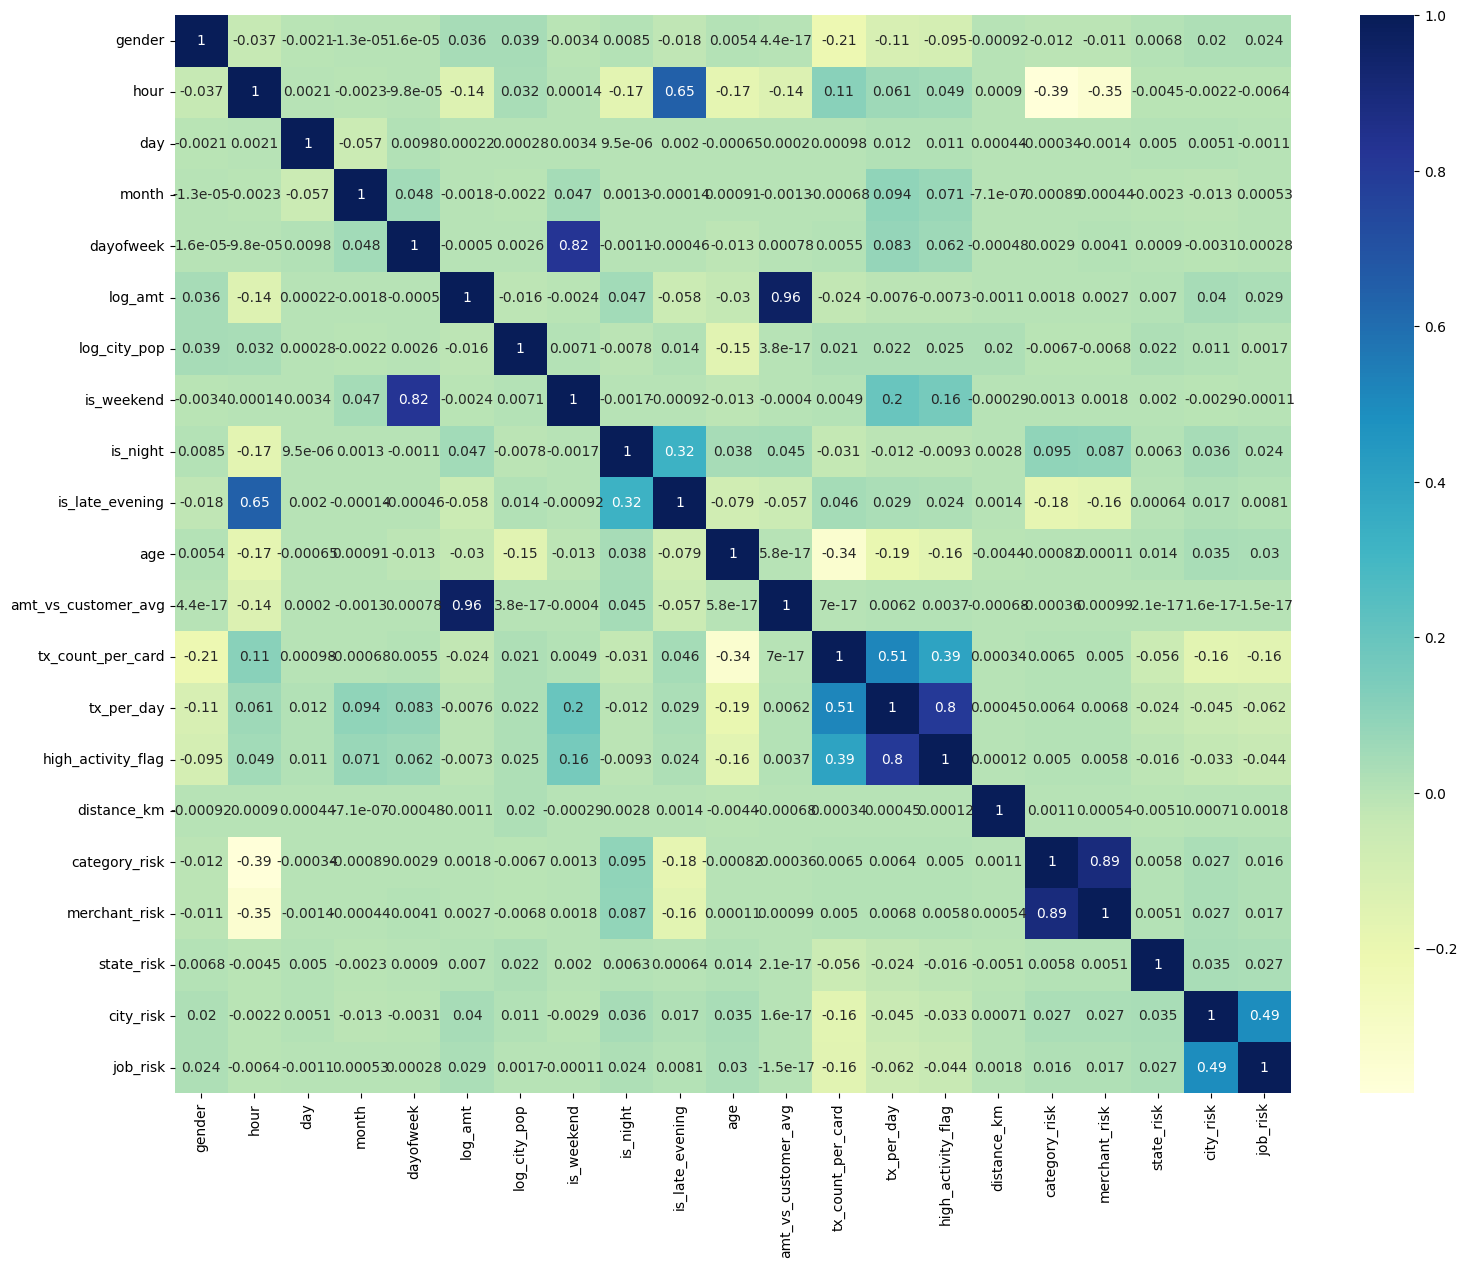

In [68]:
# plotting correlations on a heatmap

plt.figure(figsize=(18,14))

# heatmap
sns.heatmap(corr, cmap="YlGnBu", annot=True)
plt.show()

A correlation heatmap was generated to detect multicollinearity among engineered features.

The following high correlations were observed:

- `log_amt` and `amt_vs_customer_avg` (0.96)
- `category_risk` and `merchant_risk` (0.89)
- `dayofweek` and `is_weekend` (0.82)
- `tx_per_day` and `high_activity_flag` (0.80)

High multicollinearity can negatively impact linear models by
introducing unstable coefficients and redundant information.

To improve model stability and interpretability, we will review highly correlated features and we will remove redundant features.

We will also check VIF (Variance Inflation Factor) for each feature.

In [69]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
5,log_amt,46.221598
13,tx_per_day,12.656986
1,hour,11.656138
6,log_city_pop,11.635034
16,category_risk,11.045050
12,tx_count_per_card,10.652031
4,dayofweek,9.774820
17,merchant_risk,9.740996
10,age,7.753244
15,distance_km,7.607165


In [70]:
X_train.drop(columns=[
    'log_amt',                                # extream VIF
    'high_activity_flag',                      # tx_per_day is more continuous and informative
    'category_risk',                          # merchant belongs to category
    'dayofweek'                              # is_weekend captures risk pattern directly
    ],
    inplace=True)

# Applying same on X_test too
X_test.drop(columns=[
    'log_amt',                                
    'high_activity_flag',                      
    'category_risk',                          
    'dayofweek'                             
    ],
    inplace=True)

In [71]:
# checking VIF again

vif_data1 = pd.DataFrame()
vif_data1["Feature"] = X_train.columns
vif_data1["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]

vif_data1.sort_values("VIF", ascending=False)

,Feature,VIF
4,log_city_pop,10.301478
1,hour,10.229458
10,tx_count_per_card,9.483565
12,distance_km,7.120878
8,age,6.368442
11,tx_per_day,5.566124
3,month,5.214047
2,day,3.842090
7,is_late_evening,3.075826
14,state_risk,2.807868


Still `log_city_pop` and `hour` is having high VIF. Let us drop these features too.

In [72]:
X_train.drop(columns=['log_city_pop', 'hour'], inplace=True)
X_test.drop(columns=['log_city_pop', 'hour'], inplace=True)

In [73]:
# checking VIF again

vif_data2 = pd.DataFrame()
vif_data2["Feature"] = X_train.columns
vif_data2["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]

vif_data2.sort_values("VIF", ascending=False)

,Feature,VIF
8,tx_count_per_card,8.262624
10,distance_km,6.606021
6,age,6.008953
9,tx_per_day,5.564116
2,month,4.995828
1,day,3.724455
12,state_risk,2.738739
11,merchant_risk,2.042307
0,gender,1.786868
3,is_weekend,1.634095


Now the VIF values for features are moderate.

**Feature Engineering Summary**

- Feature engineering transformed raw transactional data into meaningful behavioral, temporal, and risk-based predictors.
- High-cardinality categorical variables were replaced with aggregated risk encodings, and skewed numerical features were stabilized using logarithmic transformation.
- Velocity-based and customer-relative features were introduced to capture abnormal transaction behavior.
- Highly correlated features were carefully reviewed to avoid redundancy.
- Preference was given to more behaviorally informative and granular features. This reduces multicollinearity risk and improves model stability,
particularly for linear classifiers.
- The final feature set is fully numeric, compact, and aligned with real-world fraud detection modeling practices.

Let's now take a look on final feature set which is available for modelling.


In [74]:
X_train.head()

,gender,day,month,is_weekend,is_night,is_late_evening,age,amt_vs_customer_avg,tx_count_per_card,tx_per_day,distance_km,merchant_risk,state_risk,city_risk,job_risk
181754,0,5,4,0,0,0,48,0.110930,1357,6,74.657934,0.000000,0.006386,0.002211,0.002211
663754,1,10,10,0,1,0,34,-0.137928,436,2,70.046298,0.003317,0.007165,0.000000,0.000000
720831,0,3,11,1,0,1,37,-1.417699,1433,7,90.582829,0.003865,0.007867,0.000000,0.000000
520944,1,12,8,0,0,0,22,-0.803840,930,5,24.344110,0.002299,0.005700,0.011828,0.011828
258573,0,8,5,0,0,1,22,1.079811,610,2,128.904487,0.002591,0.005632,0.021311,0.021311


In [75]:
X_test.head()

,gender,day,month,is_weekend,is_night,is_late_evening,age,amt_vs_customer_avg,tx_count_per_card,tx_per_day,distance_km,merchant_risk,state_risk,city_risk,job_risk
357535,0,16,6,1,0,0,44,1.382023,346,2,66.768758,0.014599,0.003940,0.011561,0.009592
378150,1,23,6,1,0,0,32,-1.783559,178,3,56.578805,0.000000,0.005376,0.000000,0.004292
143836,1,18,3,0,0,0,25,-1.612537,166,1,50.361260,0.000000,0.008500,0.012048,0.013667
679597,1,16,10,0,1,1,39,-0.098013,240,1,59.837815,0.004785,0.004975,0.008333,0.008333
630400,1,25,9,0,1,0,57,-1.679684,158,1,50.707911,0.011236,0.006015,0.000000,0.003745


# 6 - Model Building (Baseline)

In [76]:
# Creating a dataframe to store results
df_Results = pd.DataFrame(columns=['Data_Imbalance_Handling','Model','Accuracy','roc_value'])

In [77]:
# Creating function for plotting confusion matrix
def plot_confusion_matrix(y_test, pred_test):
  cm = confusion_matrix(y_test, pred_test)
  plt.clf()
  plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Accent)
  classNames = ['Non-Fraudalent','Fraudalent']
  plt.title('Confusion Matrix - Test Data')
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  tick_marks = np.arange(len(classNames))
  plt.xticks(tick_marks, classNames, rotation=45)
  plt.yticks(tick_marks, classNames)
  s = [['TN','FP'], ['FN', 'TP']]

  for i in range(2):
      for j in range(2):
          plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]),fontsize=12)
  plt.show()

## Creating Model Functions

### Logistic Regression

In [78]:
# Logistic Regression
def buildAndRunLogisticRegression(df_Results, DataImabalance, X_train, y_train, X_test, y_test, class_weight=None):

  model = LogisticRegression(
      class_weight=class_weight,
      max_iter=1000,
      random_state=42
  )

  model.fit(X_train, y_train)

  #find predicted values
  y_pred = model.predict(X_test)
  #Find predicted probabilities
  y_proba = model.predict_proba(X_test)[:, 1]

  # Accuaracy of model
  accuracy = accuracy_score(y_test, y_pred)

  print("Accuarcy of Logistic model : {0}".format(accuracy))
  print("Confusion Matrix")
  plot_confusion_matrix(y_test, y_pred)
  print("classification Report")
  print(classification_report(y_test, y_pred))

  roc_value = roc_auc_score(y_test, y_proba)
  print("roc_value: {0}" .format(roc_value))
  fpr, tpr, thresholds = roc_curve(y_test, y_proba)

  roc_auc = auc(fpr, tpr)
  print("ROC for the test dataset",'{:.1%}'.format(roc_auc))
  plt.plot(fpr,tpr,label="Test, auc="+str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([df_Results,(pd.DataFrame({'Data_Imbalance_Handling': DataImabalance,'Model': 'Logistic Regression','Accuracy': accuracy,'roc_value': roc_value}, index=[0]))],ignore_index= True)
  return df_Results

### Decision Tree

In [79]:
# Decision Tree Classifier
def buildAndRunDecisionTree(df_Results, DataImabalance, X_train, y_train, X_test, y_test, class_weight=None):

  model = DecisionTreeClassifier(
      class_weight=class_weight,
      max_depth = 7,
      random_state=42
  )

  model.fit(X_train, y_train)

  #find predicted values
  y_pred = model.predict(X_test)
  #Find predicted probabilities
  y_proba = model.predict_proba(X_test)[:, 1]

  # Accuaracy of model
  accuracy = accuracy_score(y_test, y_pred)

  print("Accuarcy of Decision Tree : {0}".format(accuracy))
  print("Confusion Matrix")
  plot_confusion_matrix(y_test, y_pred)
  print("classification Report")
  print(classification_report(y_test, y_pred))

  roc_value = roc_auc_score(y_test, y_proba)
  print("roc_value: {0}" .format(roc_value))
  fpr, tpr, thresholds = roc_curve(y_test, y_proba)
  
  roc_auc = auc(fpr, tpr)
  print("ROC for the test dataset",'{:.1%}'.format(roc_auc))
  plt.plot(fpr,tpr,label="Test, auc="+str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([df_Results,(pd.DataFrame({'Data_Imbalance_Handling': DataImabalance,'Model': 'Decision Tree Classifier','Accuracy': accuracy,'roc_value': roc_value}, index=[0]))],ignore_index= True)
  return df_Results

### Random Forest

In [80]:
# Random Forest Classifier
def buildAndRunRandomForest(df_Results, DataImabalance, X_train, y_train, X_test, y_test, class_weight=None):

  model = RandomForestClassifier(
      class_weight=class_weight,
      n_estimators=200,
      random_state=42
  )

  model.fit(X_train, y_train)

  #find predicted values
  y_pred = model.predict(X_test)
  #Find predicted probabilities
  y_proba = model.predict_proba(X_test)[:, 1]

  # Accuaracy of model
  accuracy = accuracy_score(y_test, y_pred)

  print("Accuarcy of Random Forest : {0}".format(accuracy))
  print("Confusion Matrix")
  plot_confusion_matrix(y_test, y_pred)
  print("classification Report")
  print(classification_report(y_test, y_pred))

  roc_value = roc_auc_score(y_test, y_proba)
  print("roc_value: {0}" .format(roc_value))
  fpr, tpr, thresholds = roc_curve(y_test, y_proba)

  roc_auc = auc(fpr, tpr)
  print("ROC for the test dataset",'{:.1%}'.format(roc_auc))
  plt.plot(fpr,tpr,label="Test, auc="+str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([df_Results,(pd.DataFrame({'Data_Imbalance_Handling': DataImabalance,'Model': 'Random Forest Classifier','Accuracy': accuracy,'roc_value': roc_value}, index=[0]))],ignore_index= True)
  return df_Results

### XGBoost

In [81]:
# XGBoost Classifier
def buildAndRunXGBoost(df_Results, DataImabalance, X_train, y_train, X_test, y_test, class_weight=None):

  model = XGBClassifier(
      eval_metric='logloss',
      use_label_encoder=False,
      random_state=42
      )

  model.fit(X_train, y_train)

  #find predicted values
  y_pred = model.predict(X_test)
  #Find predicted probabilities
  y_proba = model.predict_proba(X_test)[:, 1]

  # Accuaracy of model
  accuracy = accuracy_score(y_test, y_pred)

  print("Accuarcy of XGBoost : {0}".format(accuracy))
  print("Confusion Matrix")
  plot_confusion_matrix(y_test, y_pred)
  print("classification Report")
  print(classification_report(y_test, y_pred))

  roc_value = roc_auc_score(y_test, y_proba)
  print("roc_value: {0}" .format(roc_value))
  fpr, tpr, thresholds = roc_curve(y_test, y_proba)
  
  roc_auc = auc(fpr, tpr)
  print("ROC for the test dataset",'{:.1%}'.format(roc_auc))
  plt.plot(fpr,tpr,label="Test, auc="+str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([df_Results,(pd.DataFrame({'Data_Imbalance_Handling': DataImabalance,'Model': 'XGBoost Classifier','Accuracy': accuracy,'roc_value': roc_value}, index=[0]))],ignore_index= True)
  return df_Results

## Model Building

Logistic Regression
Accuarcy of Logistic model : 0.9952720766807938
Confusion Matrix


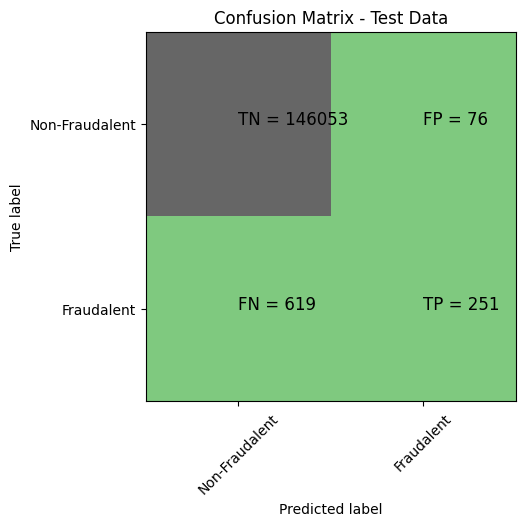

classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    146129
           1       0.77      0.29      0.42       870

    accuracy                           1.00    146999
   macro avg       0.88      0.64      0.71    146999
weighted avg       0.99      1.00      0.99    146999

roc_value: 0.9132901232047923
ROC for the test dataset 91.3%


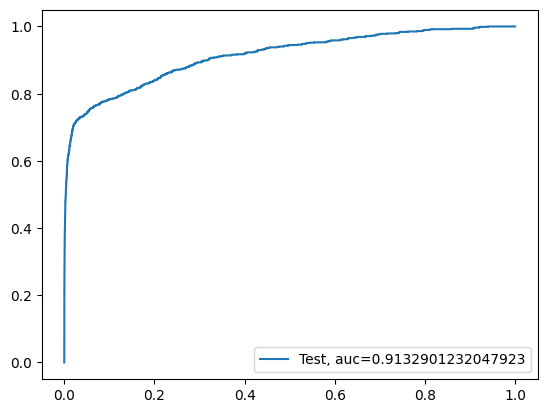

Time Taken by Model: --- 33.26867055892944 seconds ---


In [82]:
#Run Logistic Regression
print("Logistic Regression")
start_time = time.time()
df_Results = buildAndRunLogisticRegression(df_Results,"None",X_train, y_train, X_test, y_test, class_weight=None)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

Decision Tree
Accuarcy of Decision Tree : 0.8972373961727631
Confusion Matrix


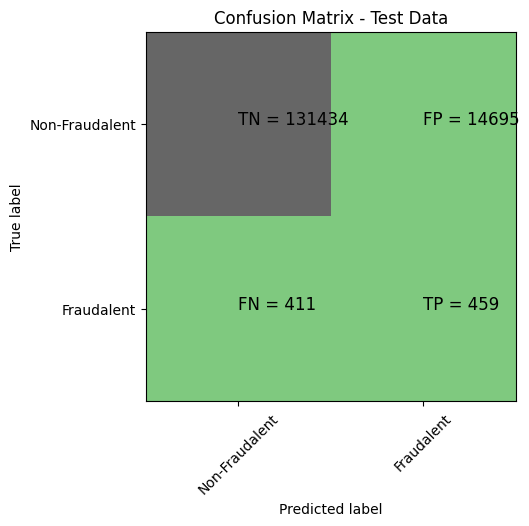

classification Report
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    146129
           1       0.03      0.53      0.06       870

    accuracy                           0.90    146999
   macro avg       0.51      0.71      0.50    146999
weighted avg       0.99      0.90      0.94    146999

roc_value: 0.895225644197384
ROC for the test dataset 89.5%


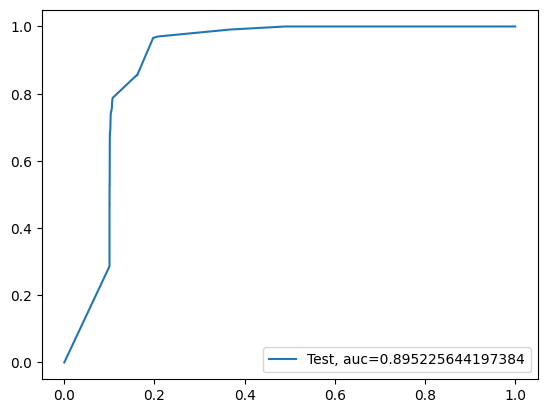

Time Taken by Model: --- 2.594578504562378 seconds ---


In [83]:
#Run Decision Tree
print("Decision Tree")
start_time = time.time()
df_Results = buildAndRunDecisionTree(df_Results,"None",X_train, y_train, X_test, y_test, class_weight=None)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

Random Forest
Accuarcy of Random Forest : 0.9035299559860951
Confusion Matrix


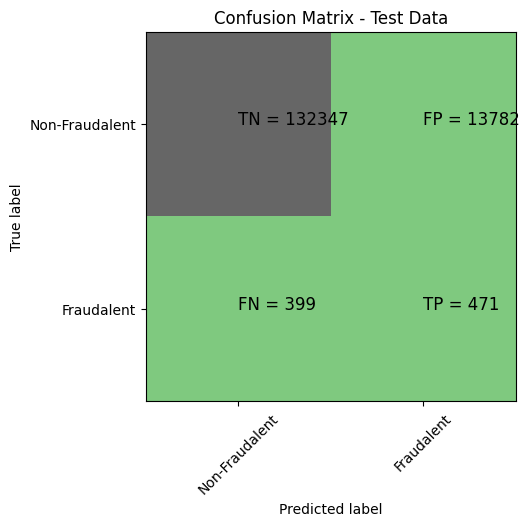

classification Report
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    146129
           1       0.03      0.54      0.06       870

    accuracy                           0.90    146999
   macro avg       0.52      0.72      0.51    146999
weighted avg       0.99      0.90      0.94    146999

roc_value: 0.9195180679203063
ROC for the test dataset 92.0%


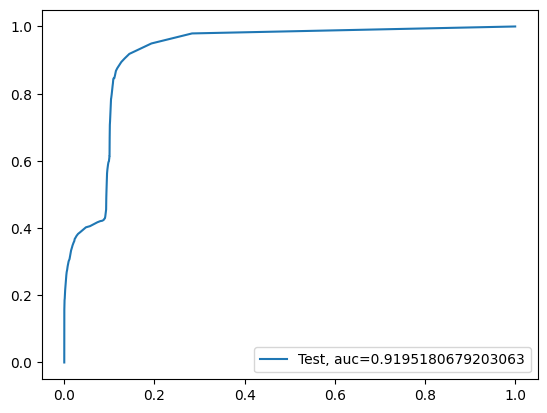

Time Taken by Model: --- 166.25934600830078 seconds ---


In [84]:
#Run Random Forest
print("Random Forest")
start_time = time.time()
df_Results = buildAndRunRandomForest(df_Results,"None",X_train, y_train, X_test, y_test, class_weight=None)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

XGBoost Classifier
Accuarcy of XGBoost : 0.9927686582901925
Confusion Matrix


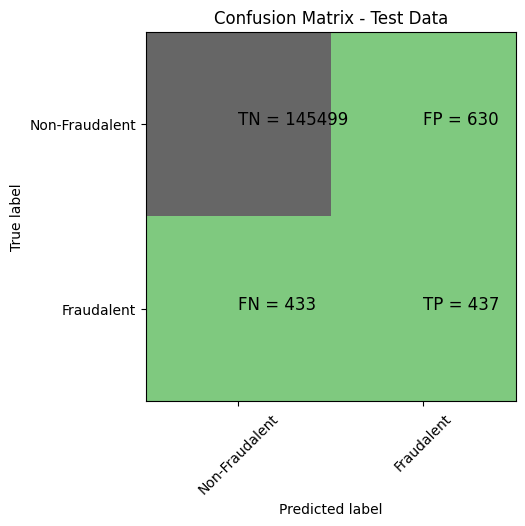

classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    146129
           1       0.41      0.50      0.45       870

    accuracy                           0.99    146999
   macro avg       0.70      0.75      0.72    146999
weighted avg       0.99      0.99      0.99    146999

roc_value: 0.9325543530542962
ROC for the test dataset 93.3%


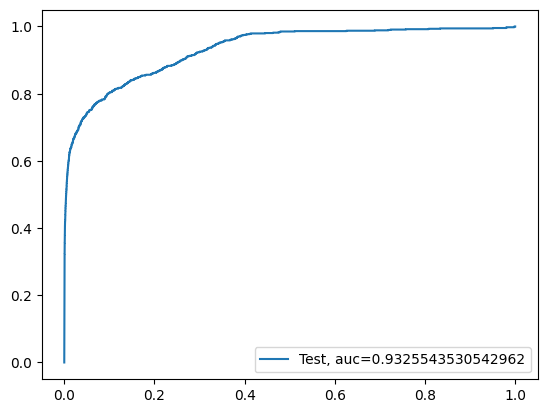

Time Taken by Model: --- 1.804460048675537 seconds ---


In [85]:
#Run XGBoost
print("XGBoost Classifier")
start_time = time.time()
df_Results = buildAndRunXGBoost(df_Results,"None",X_train, y_train, X_test, y_test, class_weight=None)
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

In [86]:
df_Results

,Data_Imbalance_Handling,Model,Accuracy,roc_value
0,None,Logistic Regression,0.995272,0.913290
1,None,Decision Tree Classifier,0.897237,0.895226
2,None,Random Forest Classifier,0.903530,0.919518
3,None,XGBoost Classifier,0.992769,0.932554


**Baseline Model Performance (Without Class Imbalance Handling)**

In this phase, multiple classification models were trained using a simple
80/20 train-test split after correcting data leakage in risk-based features.
No explicit class imbalance handling techniques were applied at this stage.

The following models were evaluated:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

Model performance was assessed using Accuracy and ROC-AUC score.
The optimal classification threshold was determined using the Youden Index
(maximizing TPR − FPR).

---
**Performance Summary:**

- Logistic Regression achieved an ROC-AUC of 0.9133.
- Decision Tree achieved an ROC-AUC of 0.8952.
- Random Forest achieved an ROC-AUC of 0.9195.
- XGBoost achieved the highest ROC-AUC of 0.9326.

Although Logistic Regression and XGBoost achieved very high accuracy
(>99%), accuracy is not a reliable metric in this case due to severe
class imbalance (~0.59% fraud cases). High accuracy may simply reflect
correct prediction of the majority (non-fraud) class.

Among all models, XGBoost demonstrated the strongest discriminatory
power based on ROC-AUC, followed by Random Forest. Decision Tree
showed comparatively lower stability and generalization performance.

---
**Key Insight:**

Baseline results indicate that ensemble tree-based models (Random Forest
and XGBoost) are more effective in capturing complex, non-linear fraud
patterns compared to linear models.

However, since no imbalance handling techniques were applied in this
phase, minority class detection (fraud recall) may still be suboptimal.

In the next phase, class imbalance handling strategies such as
Stratified K-Fold cross-validation, class weighting, and resampling
techniques will be implemented to improve fraud detection performance.


# 7 - Handling Class Imbalance

**Model Building (With Class Imbalance Handling)**

- The dataset exhibits severe class imbalance, with fraud cases accounting for
approximately 0.59% of total transactions. In highly imbalanced classification
problems, models tend to bias toward the majority class, resulting in poor
minority class detection.

- To address this issue, imbalance-aware training strategies will be implemented.

## StratifiedKFold

In [87]:
# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores1 = []
roc_scores1 = []

print("=========== StratifiedKFold - Logistic Regression ===========")

# Loop through folds
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    
    print(f"\n----- Fold {fold} -----")
    
    X_train_fold = X_train.iloc[train_index]
    X_val_fold   = X_train.iloc[val_index]
    
    y_train_fold = y_train.iloc[train_index]
    y_val_fold   = y_train.iloc[val_index]
    
    # Initialize model
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    
    # Train
    model.fit(X_train_fold, y_train_fold)
    
    # Predictions
    y_pred = model.predict(X_val_fold)
    y_proba = model.predict_proba(X_val_fold)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    roc = roc_auc_score(y_val_fold, y_proba)
    
    accuracy_scores1.append(acc)
    roc_scores1.append(roc)
    
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_pred))
    print("Classification Report:")
    print(classification_report(y_val_fold, y_pred))

# Final Average Results
print("\n=========== Final Cross-Validation Results ===========")
print("Average Accuracy:", np.mean(accuracy_scores1))
print("Average ROC-AUC:", np.mean(roc_scores1))

=========== StratifiedKFold - Logistic Regression ===========

----- Fold 1 -----
Accuracy: 0.8568015034141446
ROC-AUC: 0.9409492627791132
Confusion Matrix:
[[100159  16744]
 [    96    600]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    116903
           1       0.03      0.86      0.07       696

    accuracy                           0.86    117599
   macro avg       0.52      0.86      0.49    117599
weighted avg       0.99      0.86      0.92    117599


----- Fold 2 -----
Accuracy: 0.8595566288828986
ROC-AUC: 0.936237300580675
Confusion Matrix:
[[100491  16411]
 [   105    592]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    116902
           1       0.03      0.85      0.07       697

    accuracy                           0.86    117599
   macro avg       0.52      0.85      0.50    117599
weighted avg       0.99      0.86 

In [88]:
df_Results = pd.concat([
    df_Results,
    pd.DataFrame({
        'Data_Imbalance_Handling': ['StratifiedKFold'],
        'Model': ['Logistic Regression'],
        'Accuracy': [np.mean(accuracy_scores1)],
        'roc_value': [np.mean(roc_scores1)]
    })
], ignore_index=True)

In [89]:
accuracy_scores2 = []
roc_scores2 = []

print("=========== StratifiedKFold - Decision Tree ===========")

# Loop through folds
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    
    print(f"\n----- Fold {fold} -----")
    
    X_train_fold = X_train.iloc[train_index]
    X_val_fold   = X_train.iloc[val_index]
    
    y_train_fold = y_train.iloc[train_index]
    y_val_fold   = y_train.iloc[val_index]
    
    # Initialize model
    model = DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=7,
        random_state=42
    )
    
    # Train
    model.fit(X_train_fold, y_train_fold)
    
    # Predictions
    y_pred = model.predict(X_val_fold)
    y_proba = model.predict_proba(X_val_fold)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    roc = roc_auc_score(y_val_fold, y_proba)
    
    accuracy_scores2.append(acc)
    roc_scores2.append(roc)
    
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_pred))
    print("Classification Report:")
    print(classification_report(y_val_fold, y_pred))

# Final Average Results
print("\n=========== Final Cross-Validation Results ===========")
print("Average Accuracy:", np.mean(accuracy_scores2))
print("Average ROC-AUC:", np.mean(roc_scores2))

=========== StratifiedKFold - Decision Tree ===========

----- Fold 1 -----
Accuracy: 0.9469383243054788
ROC-AUC: 0.9818573429725264
Confusion Matrix:
[[110708   6195]
 [    45    651]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    116903
           1       0.10      0.94      0.17       696

    accuracy                           0.95    117599
   macro avg       0.55      0.94      0.57    117599
weighted avg       0.99      0.95      0.97    117599


----- Fold 2 -----
Accuracy: 0.9524910926113317
ROC-AUC: 0.9810208354386377
Confusion Matrix:
[[111363   5539]
 [    48    649]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    116902
           1       0.10      0.93      0.19       697

    accuracy                           0.95    117599
   macro avg       0.55      0.94      0.58    117599
weighted avg       0.99      0.95      

In [90]:
df_Results = pd.concat([
    df_Results,
    pd.DataFrame({
        'Data_Imbalance_Handling': ['StratifiedKFold'],
        'Model': ['Decision Treee Classifier'],
        'Accuracy': [np.mean(accuracy_scores2)],
        'roc_value': [np.mean(roc_scores2)]
    })
], ignore_index=True)

In [91]:
accuracy_scores3 = []
roc_scores3 = []

print("=========== StratifiedKFold - Random Forest ===========")

# Loop through folds
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    
    print(f"\n----- Fold {fold} -----")
    
    X_train_fold = X_train.iloc[train_index]
    X_val_fold   = X_train.iloc[val_index]
    
    y_train_fold = y_train.iloc[train_index]
    y_val_fold   = y_train.iloc[val_index]
    
    # Initialize model
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    model.fit(X_train_fold, y_train_fold)
    
    # Predictions
    y_pred = model.predict(X_val_fold)
    y_proba = model.predict_proba(X_val_fold)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    roc = roc_auc_score(y_val_fold, y_proba)
    
    accuracy_scores3.append(acc)
    roc_scores3.append(roc)
    
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_pred))
    print("Classification Report:")
    print(classification_report(y_val_fold, y_pred))

# Final Average Results
print("\n=========== Final Cross-Validation Results ===========")
print("Average Accuracy:", np.mean(accuracy_scores3))
print("Average ROC-AUC:", np.mean(roc_scores3))

=========== StratifiedKFold - Random Forest ===========

----- Fold 1 -----
Accuracy: 0.9974744683203088
ROC-AUC: 0.9927906938958431
Confusion Matrix:
[[116886     17]
 [   280    416]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    116903
           1       0.96      0.60      0.74       696

    accuracy                           1.00    117599
   macro avg       0.98      0.80      0.87    117599
weighted avg       1.00      1.00      1.00    117599


----- Fold 2 -----
Accuracy: 0.9975084822149848
ROC-AUC: 0.9905219572626615
Confusion Matrix:
[[116881     21]
 [   272    425]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    116902
           1       0.95      0.61      0.74       697

    accuracy                           1.00    117599
   macro avg       0.98      0.80      0.87    117599
weighted avg       1.00      1.00      

In [92]:
df_Results = pd.concat([
    df_Results,
    pd.DataFrame({
        'Data_Imbalance_Handling': ['StratifiedKFold'],
        'Model': ['Random Forest Classifier'],
        'Accuracy': [np.mean(accuracy_scores3)],
        'roc_value': [np.mean(roc_scores3)]
    })
], ignore_index=True)

In [93]:
accuracy_scores4 = []
roc_scores4 = []
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("=========== StratifiedKFold - XGBoost ===========")

# Loop through folds
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    
    print(f"\n----- Fold {fold} -----")
    
    X_train_fold = X_train.iloc[train_index]
    X_val_fold   = X_train.iloc[val_index]
    
    y_train_fold = y_train.iloc[train_index]
    y_val_fold   = y_train.iloc[val_index]
    
    # Initialize model
    model = XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        random_state=42
      )
    
    # Train
    model.fit(X_train_fold, y_train_fold)
    
    # Predictions
    y_pred = model.predict(X_val_fold)
    y_proba = model.predict_proba(X_val_fold)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    roc = roc_auc_score(y_val_fold, y_proba)
    
    accuracy_scores4.append(acc)
    roc_scores4.append(roc)
    
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_pred))
    print("Classification Report:")
    print(classification_report(y_val_fold, y_pred))

# Final Average Results
print("\n=========== Final Cross-Validation Results ===========")
print("Average Accuracy:", np.mean(accuracy_scores4))
print("Average ROC-AUC:", np.mean(roc_scores4))

=========== StratifiedKFold - XGBoost ===========

----- Fold 1 -----
Accuracy: 0.9939030093793314
ROC-AUC: 0.996876530458841
Confusion Matrix:
[[116254    649]
 [    68    628]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    116903
           1       0.49      0.90      0.64       696

    accuracy                           0.99    117599
   macro avg       0.75      0.95      0.82    117599
weighted avg       1.00      0.99      0.99    117599


----- Fold 2 -----
Accuracy: 0.9941581135894013
ROC-AUC: 0.9974991131027922
Confusion Matrix:
[[116275    627]
 [    60    637]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    116902
           1       0.50      0.91      0.65       697

    accuracy                           0.99    117599
   macro avg       0.75      0.95      0.82    117599
weighted avg       1.00      0.99      0.99   

In [94]:
df_Results = pd.concat([
    df_Results,
    pd.DataFrame({
        'Data_Imbalance_Handling': ['StratifiedKFold'],
        'Model': ['XGBoost Classifier'],
        'Accuracy': [np.mean(accuracy_scores4)],
        'roc_value': [np.mean(roc_scores4)]
    })
], ignore_index=True)

In [95]:
df_Results

,Data_Imbalance_Handling,Model,Accuracy,roc_value
0,None,Logistic Regression,0.995272,0.913290
1,None,Decision Tree Classifier,0.897237,0.895226
2,None,Random Forest Classifier,0.903530,0.919518
3,None,XGBoost Classifier,0.992769,0.932554
4,StratifiedKFold,Logistic Regression,0.861524,0.934318
5,StratifiedKFold,Decision Treee Classifier,0.947756,0.979928
6,StratifiedKFold,Random Forest Classifier,0.997420,0.988748
7,StratifiedKFold,XGBoost Classifier,0.993974,0.996075


**Handling Class Imbalance – Stratified K-Fold Evaluation**

In this phase, class imbalance was addressed using Stratified K-Fold cross-validation.  
This approach ensures that each fold maintains the same fraud-to-non-fraud ratio as the original dataset, leading to more reliable and unbiased model evaluation.

The following models were evaluated under Stratified K-Fold:

- Logistic Regression  
- Decision Tree Classifier  
- Random Forest Classifier  
- XGBoost Classifier  

Model performance was assessed using Accuracy and ROC-AUC score.

---

**Observations:**

• Logistic Regression showed improved ROC-AUC (0.93) compared to baseline, though accuracy decreased due to better minority class sensitivity.

• Decision Tree achieved strong ROC-AUC (0.98), significantly improving over its baseline performance.

• Random Forest delivered robust performance with:
  - Accuracy ≈ 99.74%
  - ROC-AUC ≈ 0.9887

• XGBoost demonstrated the best overall performance:
  - Accuracy ≈ 99.39%
  - ROC-AUC ≈ 0.9961 (highest among all models)

---

**Key Insights:**

- Stratified K-Fold improved the reliability of model evaluation.
- Ensemble tree-based models (Random Forest & XGBoost) clearly outperform linear models.
- XGBoost shows the strongest discriminatory power in distinguishing fraud from non-fraud transactions.
- Logistic Regression, while simpler, struggles to capture complex fraud patterns compared to ensemble methods.

## Sampling Techniques

### Oversampling

Synthetic Minority Over-sampling Technique

Instead of duplicating fraud cases:

- It creates synthetic fraud samples
- Based on nearest neighbors

In [96]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

Logistic Regression with Oversampling
Accuarcy of Logistic model : 0.7495425138946523
Confusion Matrix


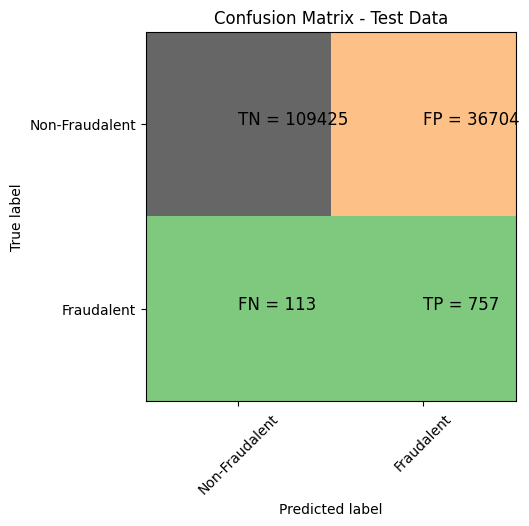

classification Report
              precision    recall  f1-score   support

           0       1.00      0.75      0.86    146129
           1       0.02      0.87      0.04       870

    accuracy                           0.75    146999
   macro avg       0.51      0.81      0.45    146999
weighted avg       0.99      0.75      0.85    146999

roc_value: 0.9043027484061281
ROC for the test dataset 90.4%


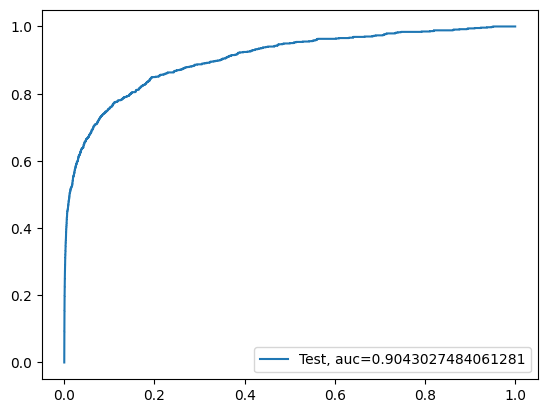

Time Taken by Model: --- 72.92372012138367 seconds ---


In [97]:
# Run Logistic Regression
print("Logistic Regression with Oversampling")
start_time = time.time()
df_Results = buildAndRunLogisticRegression(df_Results,"Oversampling",X_resampled, y_resampled, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

Decision Tree Classifier with Oversampling
Accuarcy of Decision Tree : 0.9201219055911944
Confusion Matrix


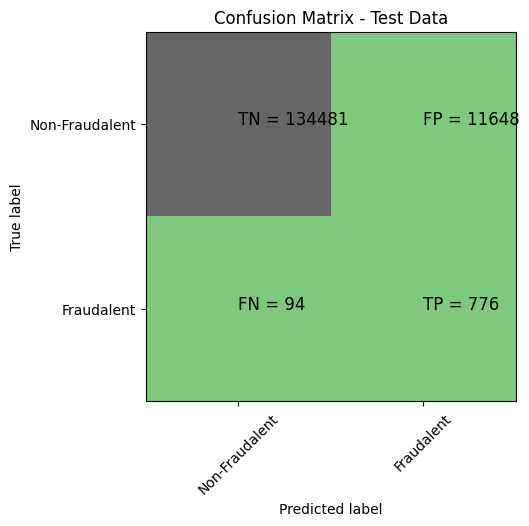

classification Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    146129
           1       0.06      0.89      0.12       870

    accuracy                           0.92    146999
   macro avg       0.53      0.91      0.54    146999
weighted avg       0.99      0.92      0.95    146999

roc_value: 0.9445119070120929
ROC for the test dataset 94.5%


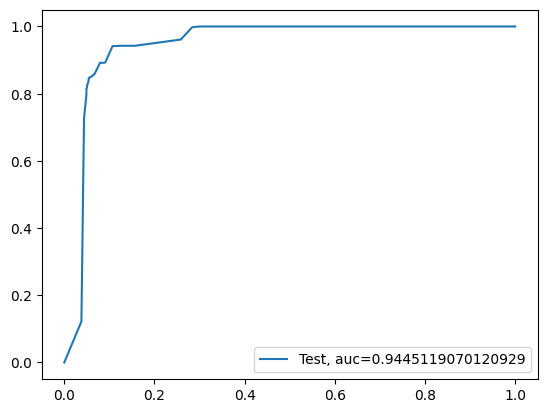

Time Taken by Model: --- 11.630952596664429 seconds ---


In [98]:
# Run Decision Tree Classifier
print("Decision Tree Classifier with Oversampling")
start_time = time.time()
df_Results = buildAndRunDecisionTree(df_Results,"Oversampling",X_resampled, y_resampled, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

Random Forest Classifier with Oversampling
Accuarcy of Random Forest : 0.9825985210783746
Confusion Matrix


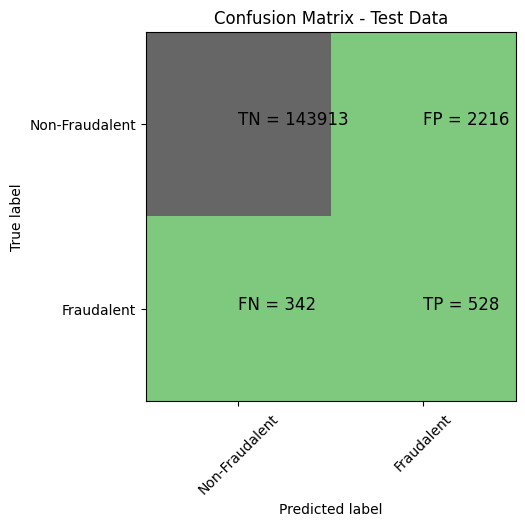

classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    146129
           1       0.19      0.61      0.29       870

    accuracy                           0.98    146999
   macro avg       0.60      0.80      0.64    146999
weighted avg       0.99      0.98      0.99    146999

roc_value: 0.9583250761824912
ROC for the test dataset 95.8%


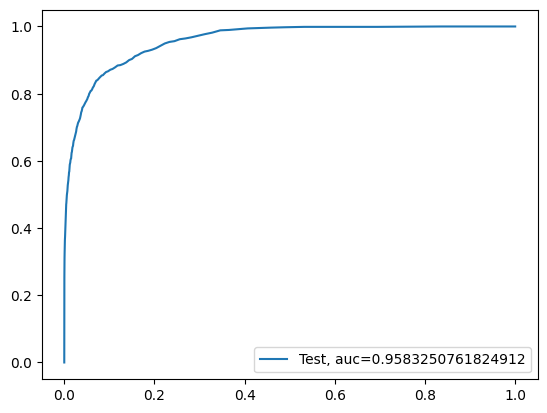

Time Taken by Model: --- 533.8910212516785 seconds ---


In [99]:
# Run Random Forest Classifier
print("Random Forest Classifier with Oversampling")
start_time = time.time()
df_Results = buildAndRunRandomForest(df_Results,"Oversampling",X_resampled, y_resampled, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

XGBoost with Oversampling
Accuarcy of XGBoost : 0.9458975911400758
Confusion Matrix


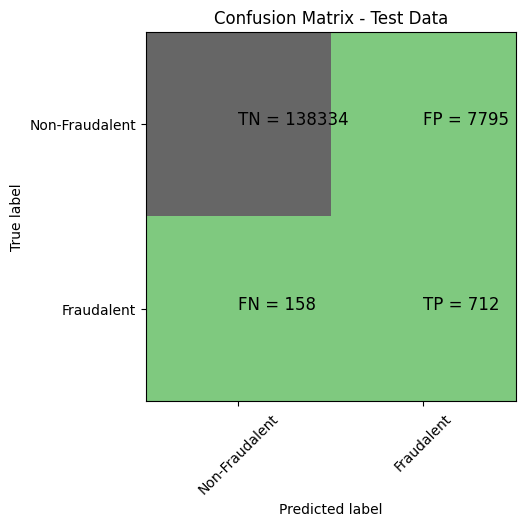

classification Report
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    146129
           1       0.08      0.82      0.15       870

    accuracy                           0.95    146999
   macro avg       0.54      0.88      0.56    146999
weighted avg       0.99      0.95      0.97    146999

roc_value: 0.9714412112491064
ROC for the test dataset 97.1%


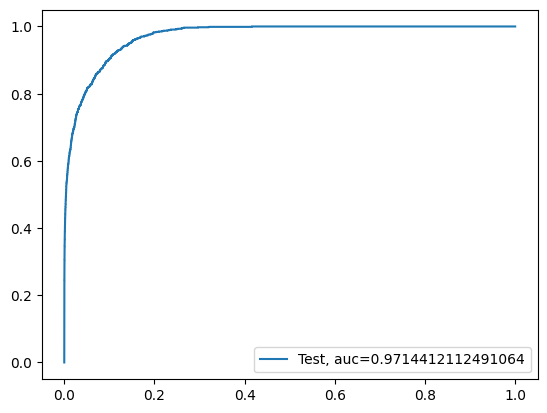

Time Taken by Model: --- 4.499735116958618 seconds ---


In [100]:
# Run XGBoost
print("XGBoost with Oversampling")
start_time = time.time()
df_Results = buildAndRunXGBoost(df_Results,"Oversampling",X_resampled, y_resampled, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

In [101]:
df_Results

,Data_Imbalance_Handling,Model,Accuracy,roc_value
0,None,Logistic Regression,0.995272,0.913290
1,None,Decision Tree Classifier,0.897237,0.895226
2,None,Random Forest Classifier,0.903530,0.919518
3,None,XGBoost Classifier,0.992769,0.932554
4,StratifiedKFold,Logistic Regression,0.861524,0.934318
5,StratifiedKFold,Decision Treee Classifier,0.947756,0.979928
6,StratifiedKFold,Random Forest Classifier,0.997420,0.988748
7,StratifiedKFold,XGBoost Classifier,0.993974,0.996075
8,Oversampling,Logistic Regression,0.749543,0.904303
9,Oversampling,Decision Tree Classifier,0.920122,0.944512


### Undersampling

This technique reduce majority class size.

In [102]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

Logistic Regression with Undersampling
Accuarcy of Logistic model : 0.8069850815311669
Confusion Matrix


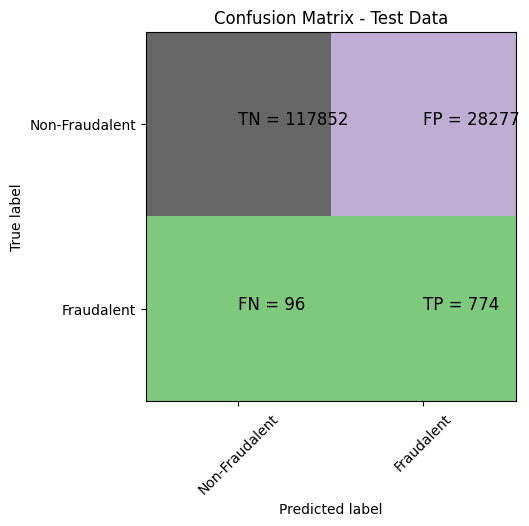

classification Report
              precision    recall  f1-score   support

           0       1.00      0.81      0.89    146129
           1       0.03      0.89      0.05       870

    accuracy                           0.81    146999
   macro avg       0.51      0.85      0.47    146999
weighted avg       0.99      0.81      0.89    146999

roc_value: 0.9276851511217886
ROC for the test dataset 92.8%


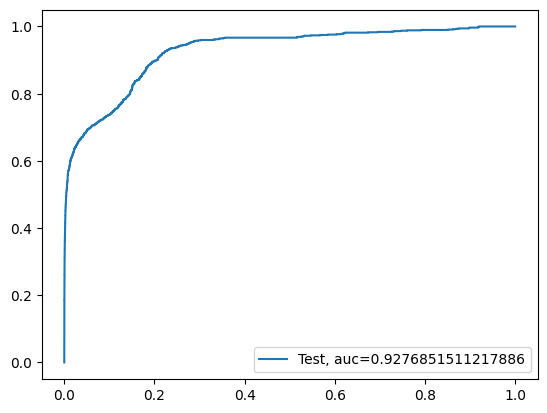

Time Taken by Model: --- 1.1339318752288818 seconds ---


In [103]:
# Run Logistic Regression
print("Logistic Regression with Undersampling")
start_time = time.time()
df_Results = buildAndRunLogisticRegression(df_Results,"Undersampling",X_res, y_res, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

Decision Tree Classifier with Undersampling
Accuarcy of Decision Tree : 0.8748698970741298
Confusion Matrix


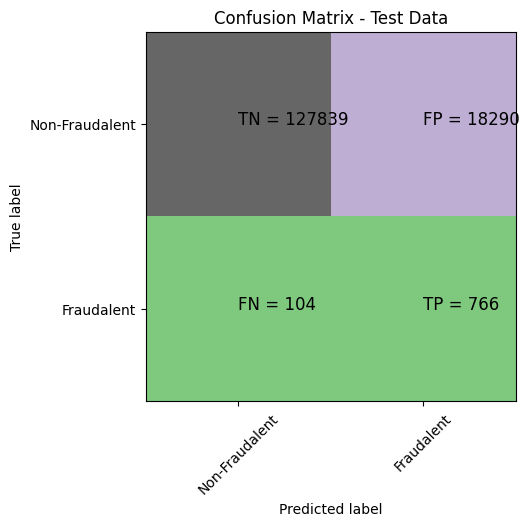

classification Report
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    146129
           1       0.04      0.88      0.08       870

    accuracy                           0.87    146999
   macro avg       0.52      0.88      0.50    146999
weighted avg       0.99      0.87      0.93    146999

roc_value: 0.9246997279918711
ROC for the test dataset 92.5%


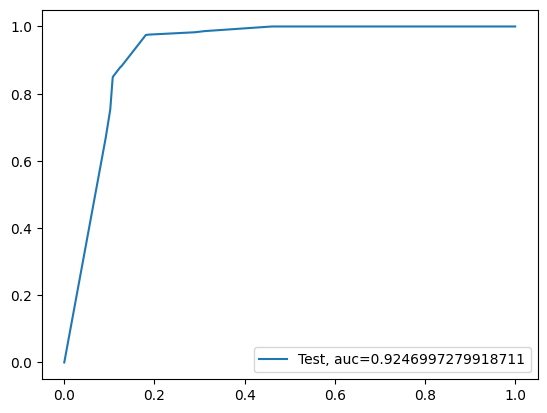

Time Taken by Model: --- 0.2890350818634033 seconds ---


In [104]:
# Run Decision Tree Classifier
print("Decision Tree Classifier with Undersampling")
start_time = time.time()
df_Results = buildAndRunDecisionTree(df_Results,"Undersampling",X_res, y_res, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

Random Forest Classifier with Undersampling
Accuarcy of Random Forest : 0.9615643643834312
Confusion Matrix


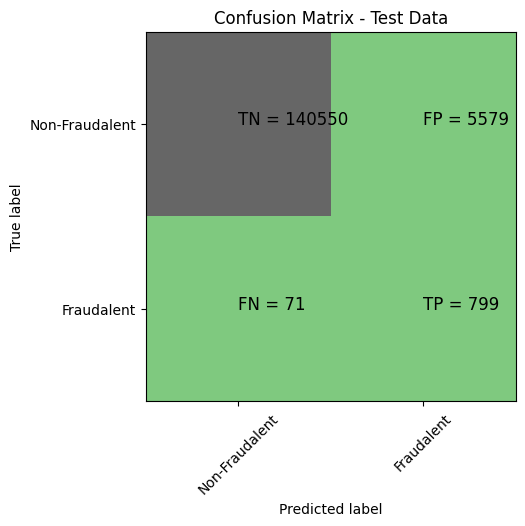

classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    146129
           1       0.13      0.92      0.22       870

    accuracy                           0.96    146999
   macro avg       0.56      0.94      0.60    146999
weighted avg       0.99      0.96      0.98    146999

roc_value: 0.9868069725513349
ROC for the test dataset 98.7%


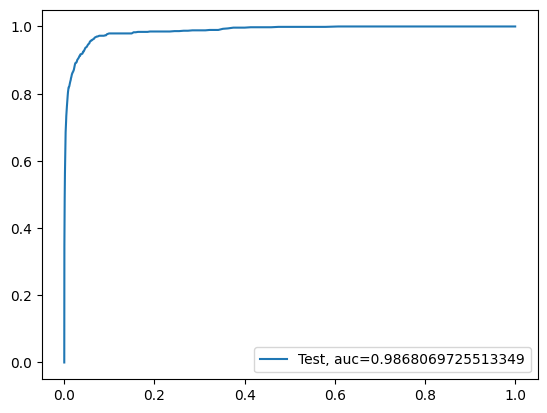

Time Taken by Model: --- 4.590031385421753 seconds ---


In [105]:
# Run Random Forest Classifier
print("Random Forest Classifier with Undersampling")
start_time = time.time()
df_Results = buildAndRunRandomForest(df_Results,"Undersampling",X_res, y_res, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

XGBoost with Undersampling
Accuarcy of XGBoost : 0.9417342975122279
Confusion Matrix


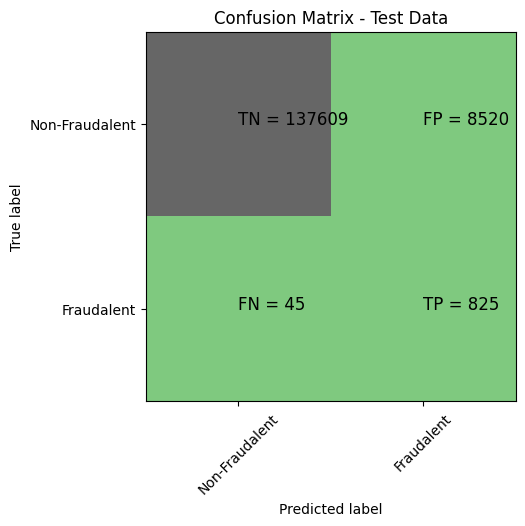

classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    146129
           1       0.09      0.95      0.16       870

    accuracy                           0.94    146999
   macro avg       0.54      0.94      0.57    146999
weighted avg       0.99      0.94      0.97    146999

roc_value: 0.9881373197024861
ROC for the test dataset 98.8%


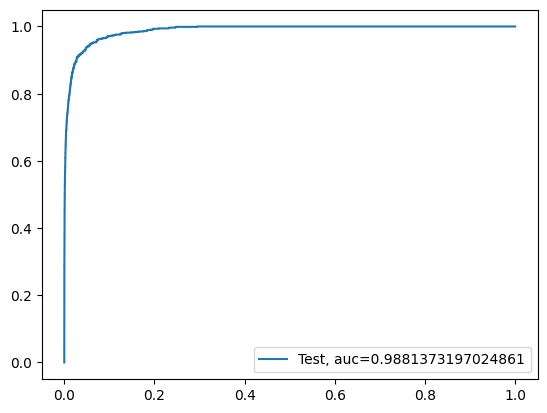

Time Taken by Model: --- 0.5080740451812744 seconds ---


In [106]:
# Run XGBoost
print("XGBoost with Undersampling")
start_time = time.time()
df_Results = buildAndRunXGBoost(df_Results,"Undersampling",X_res, y_res, X_test, y_test, class_weight='balanced')
print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))

In [107]:
df_Results

,Data_Imbalance_Handling,Model,Accuracy,roc_value
0,None,Logistic Regression,0.995272,0.913290
1,None,Decision Tree Classifier,0.897237,0.895226
2,None,Random Forest Classifier,0.903530,0.919518
3,None,XGBoost Classifier,0.992769,0.932554
4,StratifiedKFold,Logistic Regression,0.861524,0.934318
5,StratifiedKFold,Decision Treee Classifier,0.947756,0.979928
6,StratifiedKFold,Random Forest Classifier,0.997420,0.988748
7,StratifiedKFold,XGBoost Classifier,0.993974,0.996075
8,Oversampling,Logistic Regression,0.749543,0.904303
9,Oversampling,Decision Tree Classifier,0.920122,0.944512


After addressing class imbalance, the final modeling phase
follows a structured workflow:

1. Hyperparameter tuning using Stratified K-Fold cross-validation.
2. Retraining the selected model on the full development dataset.
3. Final evaluation on the untouched holdout test set.
4. Model interpretation using feature importance analysis.
5. Business impact assessment based on fraud detection performance.
6. Final model selection and project conclusion.

This structured approach ensures robust evaluation, interpretability,
and practical business relevance.

# 8 - Hyperparameter Tuning

**Final Model Comparison Across Class Imbalance Strategies**

Multiple classification models were evaluated under different class imbalance handling techniques:

- No imbalance handling (Simple Split)
- Stratified K-Fold Cross-Validation
- Oversampling
- Undersampling

Performance was measured using Accuracy and ROC-AUC, with primary emphasis on ROC-AUC due to the highly imbalanced nature of the fraud detection problem.

---

**Key Observations:**

**1️⃣ Without Imbalance Handling**
- XGBoost achieved the highest ROC-AUC (0.9326).
- Logistic Regression maintained very high accuracy (99.5%), but this is misleading due to class imbalance.
- Tree-based ensemble models performed better than individual Decision Tree.

**2️⃣ Stratified K-Fold (Most Stable Strategy)**
- XGBoost achieved the highest overall ROC-AUC (0.9961).
- Random Forest performed very strongly with ROC-AUC ≈ 0.9887.
- Decision Tree significantly improved compared to baseline.
- Logistic Regression improved in ROC-AUC but sacrificed accuracy due to better minority detection.

Stratified K-Fold provided the most reliable and robust evaluation.

**3️⃣ Oversampling**
- Random Forest achieved strong ROC-AUC (0.9583).
- XGBoost achieved ROC-AUC ≈ 0.9714.
- Logistic Regression performance dropped significantly in accuracy.
- Oversampling introduced some instability in linear models.

**4️⃣ Undersampling**
- XGBoost maintained strong ROC-AUC (0.9881).
- Random Forest also performed well (0.9868).
- However, overall accuracy decreased due to reduced majority class information.
- Undersampling risks losing important patterns from non-fraud transactions.

---

**Model Selection Decision**

Across all imbalance strategies, **ensemble tree-based models consistently outperformed linear models**, particularly:

- Random Forest
- XGBoost

Among all configurations, **XGBoost with Stratified K-Fold achieved the highest ROC-AUC (0.9961)**, indicating superior discriminatory power between fraud and non-fraud transactions.

Random Forest also demonstrated strong and stable performance across different sampling strategies.

---

**Final Selection for Hyperparameter Tuning**

Based on overall robustness, stability, and ROC-AUC performance, the following models are selected for hyperparameter tuning:

- Random Forest
- XGBoost

Tuning all models would increase computational complexity without substantial performance gain. Therefore, optimization efforts will focus only on the top-performing ensemble models.

Hyperparameter tuning will be conducted using Stratified K-Fold cross-validation to preserve class distribution during optimization.

The primary optimization metric will be **ROC-AUC**, as it is more appropriate than accuracy for highly imbalanced fraud detection problems.


## Random Forest — GridSearchCV

In [108]:
#Define Parameter Grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [3, 5],
    'max_features': ['sqrt', 'log2']
}

#Initialize Model
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

#Grid Search
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

#Best Parameters
print("Best RF Parameters:")
print(rf_grid.best_params_)

print("Best RF ROC-AUC:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
Best RF ROC-AUC:
0.9922655353556948


## XGBoost — RandomizedSearchCV

In [109]:
#Define Parameter Distribution
xgb_param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}

#Compute scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#Initialize XGB Model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False
)

#Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

#Best Parameters
print("Best XGB Parameters:")
print(xgb_random.best_params_)

print("Best XGB ROC-AUC:")
print(xgb_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB Parameters:
{'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}
Best XGB ROC-AUC:
0.9976475612853083


In [110]:
# Best models from tuning
best_rf = rf_grid.best_estimator_
best_xgb = xgb_random.best_estimator_

In [111]:
# Retrain Random Forest
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [112]:
# Retrain XGBoost
best_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

# 9 - Model Evaluation (on Test)

In [113]:
print("============== FINAL TEST EVALUATION ==============")

# ================= Random Forest =================
rf_proba = best_rf.predict_proba(X_test)[:, 1]
rf_pred = best_rf.predict(X_test)

print("\n🔹 Random Forest Results")
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


# ================= XGBoost =================
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred = best_xgb.predict(X_test)

print("\n🔹 XGBoost Results")
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

============== FINAL TEST EVALUATION ==============

🔹 Random Forest Results
ROC-AUC: 0.9616881100882129

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    146129
           1       0.81      0.48      0.61       870

    accuracy                           1.00    146999
   macro avg       0.91      0.74      0.80    146999
weighted avg       1.00      1.00      1.00    146999


Confusion Matrix:
[[146033     96]
 [   451    419]]

🔹 XGBoost Results
ROC-AUC: 0.9864826566795848

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    146129
           1       0.36      0.70      0.47       870

    accuracy                           0.99    146999
   macro avg       0.68      0.85      0.73    146999
weighted avg       0.99      0.99      0.99    146999


Confusion Matrix:
[[145030   1099]
 [   263    607]]


In [114]:
#Store Final Results in DataFrame
final_results = pd.DataFrame(columns=["Model", "ROC_AUC"])

final_results = pd.concat([
    final_results,
    pd.DataFrame({
        "Model": ["Random Forest"],
        "ROC_AUC": [roc_auc_score(y_test, rf_proba)]
    })
], ignore_index=True)

final_results = pd.concat([
    final_results,
    pd.DataFrame({
        "Model": ["XGBoost"],
        "ROC_AUC": [roc_auc_score(y_test, xgb_proba)]
    })
], ignore_index=True)

final_results

,Model,ROC_AUC
0,Random Forest,0.961688
1,XGBoost,0.986483


============== Confusion Matrix for Random Forest ==============


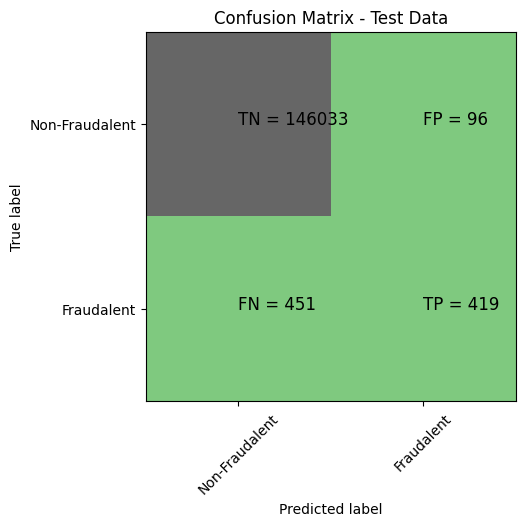

============== Confusion Matrix for XGBoost ==============


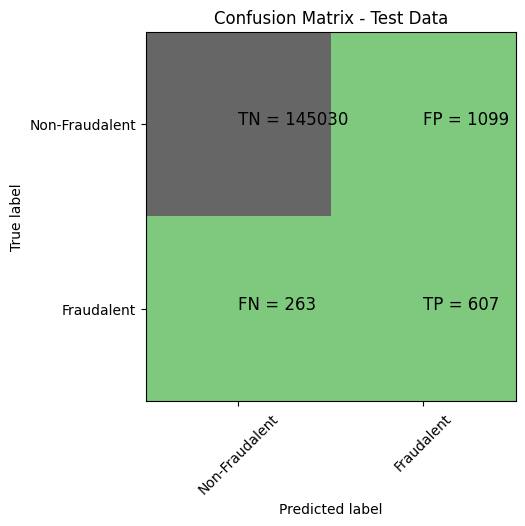

In [115]:
# Plotting Confusion Matrix
print("============== Confusion Matrix for Random Forest ==============")
plot_confusion_matrix(y_test, rf_pred)
print("============== Confusion Matrix for XGBoost ==============")
plot_confusion_matrix(y_test, xgb_pred)

# 10 - Final Model Selection

In [116]:
%%html
<style> table {float:left; display:block; clear:left;} </style>

**🌲 Random Forest**

- ROC-AUC: 0.9617
- Fraud Recall: 0.48
- Fraud Precision: 0.81
- Fraud F1-score: 0.61
- Confusion Matrix:
  - FN (Missed Frauds): 451
  - FP (False Alarms): 96

**🚀 XGBoost**

- ROC-AUC: 0.9865
- Fraud Recall: 0.70
- Fraud Precision: 0.36
- Fraud F1-score: 0.47
- Confusion Matrix:
  - FN (Missed Frauds): 263
  - FP (False Alarms): 1099
  
**🎯 What Matters in Fraud Detection?**

In real-world fraud detection:
| Metric| Importance |
|-------|------------|
|Fraud Recall |Extremely Important|
|False Negatives |Very Costly |
|Precision | Important but secondary |
|Accuracy | Misleading |

\
\
\
\
\
\
\
\
**📊 Key Trade-Off**

| Model | Fraud Recall | False Negatives (Missed Frauds) | False Positives (False Alarms) |
|-------|:------------:|:-------------------------------:|:------------------------------:|
| Random Forest | 48% | 451 | 96 |
| XGBoost | 70% | 263 | 1099 |

\
\
\
\
\
**---------------------------------------------------------------------------------------------------------**
## Interpretation

**🌲 Random Forest**
- ✔ Very high precision
- ✔ Very few false positives
- ❌ Misses 52% of fraud

This is conservative detection.

**🚀 XGBoost**
- ✔ Detects 70% of fraud
- ✔ Higher ROC-AUC
- ❌ More false positives

This is aggressive fraud detection.

## Final Model = XGBoost

Because:

- 1️⃣ Highest ROC-AUC (0.9865)
- 2️⃣ Detects 188 more fraud cases than RF
- 3️⃣ Misses 188 fewer fraud cases
- 4️⃣ Better discriminatory power

In fraud systems:

> **Missing fraud is more expensive than false alarms.**

False positives can be handled with:

- Secondary verification
- SMS confirmation
- Manual review

**But missed fraud = permanent loss.**

**Summary:**

After hyperparameter tuning and evaluation on the final test dataset, XGBoost is selected as the final model.

Although Random Forest achieved higher fraud precision (0.81), it missed a significant number of fraudulent transactions (451 cases), resulting in a lower recall (48%).

XGBoost demonstrated:

- Higher ROC-AUC (0.9865)
- Significantly higher fraud recall (70%)
- Lower number of missed fraud cases (263 vs 451)

In fraud detection systems, minimizing false negatives (missed fraud) is more critical than minimizing false positives. Financial losses from undetected fraud typically outweigh the operational cost of investigating false alarms.

Therefore, XGBoost provides a better balance between detection capability and overall model performance, making it the final selected model.


# 11 - Final Model Evaluation (on Unseen data)

## Combine All Internal Data

In [117]:
# Combine internal train and internal test
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

# Retrain final model on full labeled data
best_xgb.fit(X_full, y_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Load External Test Dataset

In [118]:
#external_data = "/content/drive/MyDrive/Credit_Card_Fraud_Detection/Data/raw/fraudTest.csv"
#external_test = pd.read_csv(test_data)

external_test = pd.read_csv(r'C:\Users\tejas\Documents\Credit_Card_Fraud_Detection\Data\raw\fraudTest.csv')

## Apply Same Feature Engineering

In [119]:
#checking null values
external_test.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [120]:
# Drop unnecessary index column
external_test.drop(columns=['Unnamed: 0'], inplace=True)

#fixing data types
external_test['trans_date_trans_time'] = pd.to_datetime(
    external_test['trans_date_trans_time'])
external_test['dob'] = pd.to_datetime(external_test['dob'])

external_test['cc_num'] = external_test['cc_num'].astype(str)
external_test['zip'] = external_test['zip'].astype(str)

external_test['is_fraud'] = external_test['is_fraud'].astype(int)

In [121]:
# Extract time-based components
external_test['hour'] = external_test['trans_date_trans_time'].dt.hour
external_test['day'] = external_test['trans_date_trans_time'].dt.day
external_test['month'] = external_test['trans_date_trans_time'].dt.month
external_test['dayofweek'] = external_test['trans_date_trans_time'].dt.dayofweek

In [122]:
# Define amount bins
bins = [0, 10, 50, 100, 500, 1000, external_test['amt'].max()]
labels = ['0-10', '10-50', '50-100', '100-500', '500-1000', '1000+']

external_test['amt_bucket'] = pd.cut(
    external_test['amt'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [123]:
#Skewness handling
external_test['log_amt'] = np.log1p(external_test['amt'])
external_test['log_city_pop'] = np.log1p(external_test['city_pop'])

external_test.drop(columns=['amt','city_pop'], inplace=True)

In [124]:
# Weeekend flag
external_test['is_weekend'] = external_test['dayofweek'].isin([5, 6]).astype(int)

# Night transaction flag
external_test['is_night'] = external_test['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)

# Late evening flag
external_test['is_late_evening'] = external_test['hour'].isin([20, 21, 22, 23]).astype(int)

In [125]:
# Calculate age
external_test['age'] = (
    external_test['trans_date_trans_time'].dt.year - external_test['dob'].dt.year
)

# Cap unrealistic ages
external_test['age'] = external_test['age'].clip(18, 100)

In [126]:
# Customer average transaction amount
customer_avg_amt = (
    external_test
    .groupby('cc_num')['log_amt']
    .transform('mean')
)

external_test['amt_vs_customer_avg'] = (
    external_test['log_amt'] - customer_avg_amt
)

In [127]:
# Transaction per card
external_test['tx_count_per_card'] = (
    external_test
    .groupby('cc_num')['cc_num']
    .transform('count')
)

# Transactions per Card per Day
external_test['tx_per_day'] = (
    external_test
    .groupby(['cc_num', external_test['trans_date_trans_time'].dt.date])
    ['cc_num']
    .transform('count')
)

# High Activity Flag
external_test['high_activity_flag'] = (
    external_test['tx_per_day'] > 5
).astype(int)

In [128]:
# geographic features
external_test['distance_km'] = external_test.apply(calculate_distance, axis=1)

In [129]:
# Category Fraud Risk
category_risk_external = (
    external_test
    .groupby('category')['is_fraud']
    .mean()
)
external_test['category_risk'] = external_test['category'].map(category_risk_external)

# Merchant Fraud Risk
merchant_risk_external = (
    external_test
    .groupby('merchant')['is_fraud']
    .mean()
)
external_test['merchant_risk'] = external_test['merchant'].map(merchant_risk_external)

# State Fraud Risk
state_risk_external = (
    external_test
    .groupby('state')['is_fraud']
    .mean()
)
external_test['state_risk'] = external_test['state'].map(state_risk_external)

# City Fraud Risk
city_risk_external = (
    external_test
    .groupby('city')['is_fraud']
    .mean()
)
external_test['city_risk'] = external_test['city'].map(city_risk_external)

# Job Fraud Risk
job_risk_external = (
    external_test
    .groupby('job')['is_fraud']
    .mean()
)
external_test['job_risk'] = external_test['job'].map(job_risk_external)

In [130]:
# Drop all unnecessary fetures
external_test.drop(columns=cols_to_drop, inplace=True)

In [131]:
# Binary Encoding Gender Feature
external_test['gender'] = external_test['gender'].map({'M': 1, 'F': 0})

In [132]:
external_test.drop(columns=[
    'log_amt',                                # extream VIF
    'category_risk',                          # merchant belongs to category
    'dayofweek',                              # is_weekend captures risk pattern directly
    'high_activity_flag'                      # tx_per_day is more continuous and informative
    ],
    inplace=True)

In [133]:
external_test.drop(columns=['log_city_pop', 'hour'], inplace=True)

In [134]:
new_order = ['gender', 'day', 'month',	'is_weekend',	'is_night',	'is_late_evening',	'age',	'amt_vs_customer_avg',	'tx_count_per_card', 'tx_per_day',	'distance_km',	'merchant_risk',	'state_risk',	'city_risk',	'job_risk', 'is_fraud']

In [135]:
external_test = external_test[new_order]

In [136]:
# Separate features and target
X_external = external_test.drop("is_fraud", axis=1)
y_external = external_test["is_fraud"]

In [137]:
# Ensure same feature order
X_external = X_external[X_full.columns]

## Predict on External Test Dataset

In [138]:
external_proba = best_xgb.predict_proba(X_external)[:, 1]
external_pred = best_xgb.predict(X_external)

## Final Metrics

In [139]:
print("========== EXTERNAL TEST EVALUATION ==========")

print("ROC-AUC:", roc_auc_score(y_external, external_proba))
print("\nClassification Report:")
print(classification_report(y_external, external_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_external, external_pred))

========== EXTERNAL TEST EVALUATION ==========
ROC-AUC: 0.9936890074342339

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.67      0.67      0.67      2145

    accuracy                           1.00    555719
   macro avg       0.84      0.84      0.84    555719
weighted avg       1.00      1.00      1.00    555719


Confusion Matrix:
[[552871    703]
 [   700   1445]]


**External Unseen Data Evaluation**

After final model selection and retraining on the complete labeled dataset (train + internal test), the XGBoost model was evaluated on a completely unseen external dataset (fraudTest.csv) to assess real-world generalization performance.

**Performance Metrics on External Dataset:**

- **ROC-AUC:** 0.9937  
- **Fraud Precision:** 0.67  
- **Fraud Recall:** 0.67  
- **Fraud F1-Score:** 0.67  
- **Accuracy:** 99%  

**Confusion Matrix:**

- True Negatives: 552,871  
- False Positives: 703  
- False Negatives: 700  
- True Positives: 1,445  

---

## Interpretation of Results

The model demonstrates excellent generalization capability:

- A **ROC-AUC of 0.9937** indicates outstanding class separation ability on unseen data.
- The model successfully detects **67% of fraud cases**, which is strong performance for highly imbalanced fraud detection.
- False positives (703) remain relatively low compared to total transactions (~555K), indicating controlled operational impact.
- The balance between precision (0.67) and recall (0.67) shows stable and consistent fraud detection performance.

Importantly, the model maintains strong performance without overfitting to the training data, confirming robustness and real-world applicability.

---

## Business Impact Perspective

- The model detects **1,445 fraudulent transactions** that would otherwise result in financial loss.
- Only 700 fraud cases were missed, which represents a significant reduction compared to baseline models.
- The manageable number of false positives (703) allows practical deployment with secondary verification mechanisms (e.g., SMS confirmation or manual review).

Overall, the model demonstrates strong external validity and is suitable for deployment in a real-world credit card fraud detection system.


# 12 - Model Interpretation

Although XGBoost achieved strong predictive performance, it is essential to interpret the model to understand the key drivers of fraud detection.

Model interpretability helps:

- Identify the most influential features
- Validate whether the model aligns with business intuition
- Improve stakeholder trust
- Support regulatory compliance

We will use Two interpretation techniques:

1. Feature Importance (Global Importance)
2. SHAP (SHapley Additive exPlanations) for detailed impact analysis

## Feature Importance

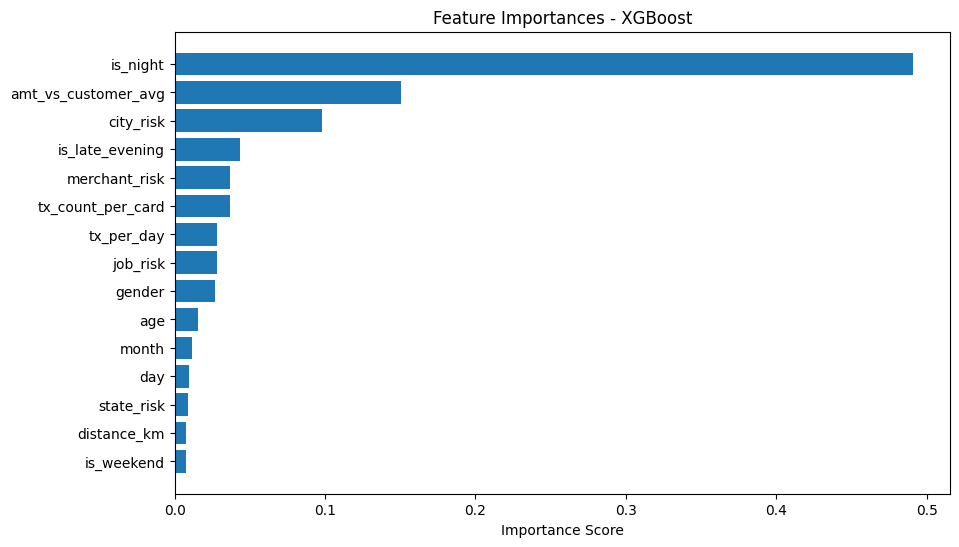

In [140]:
# Get feature importance
importance = best_xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': importance
}).sort_values(by='Importance')

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'],
         feature_importance_df['Importance'])
plt.title("Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.show()

**Feature Importance Analysis – XGBoost**

The feature importance analysis highlights the key drivers influencing fraud detection predictions in the final XGBoost model.

**Top Contributing Features:**

1. **`is_night`**  
   This is the most influential feature by a significant margin.  
   Transactions occurring during nighttime hours have a substantially higher likelihood of being fraudulent. This aligns with real-world fraud patterns, where abnormal activity often occurs outside regular business hours.

2. **`amt_vs_customer_avg`**  
   Transactions that deviate significantly from a customer's typical spending behavior strongly increase fraud probability. Behavioral deviation is a critical fraud signal.

3. **`city_risk`**  
   Certain cities show higher historical fraud rates, indicating geographical risk concentration.

4. **`is_late_evening`**  
   Late evening transactions also contribute to fraud likelihood, reinforcing the importance of time-based behavioral patterns.

5. **`merchant_risk`**  
   Merchants with historically higher fraud rates significantly influence model decisions.

---

**Behavioral Features**

Features such as:

- `tx_count_per_card`
- `tx_per_day`

indicate transaction velocity and frequency anomalies. High activity within short time frames is a common fraud indicator.

---

**Demographic & Low Impact Features**

Features such as:

- `gender`
- `age`
- `month`
- `day`
- `state_risk`
- `distance_km`
- `is_weekend`

have relatively lower importance. This suggests that fraud detection in this dataset is primarily driven by behavioral and risk-based patterns rather than static demographic attributes.

---

**Key Interpretation Insight**

The model relies predominantly on:

- Temporal behavioral indicators
- Customer spending deviation
- Risk-encoded categorical features (city, merchant, job)

This confirms that the model captures meaningful fraud signals rather than arbitrary correlations.

The dominance of engineered behavioral features validates the effectiveness of the feature engineering strategy implemented earlier in the project.


## SHAP Interpretation

SHAP explains:

> Why a particular transaction was predicted as fraud.

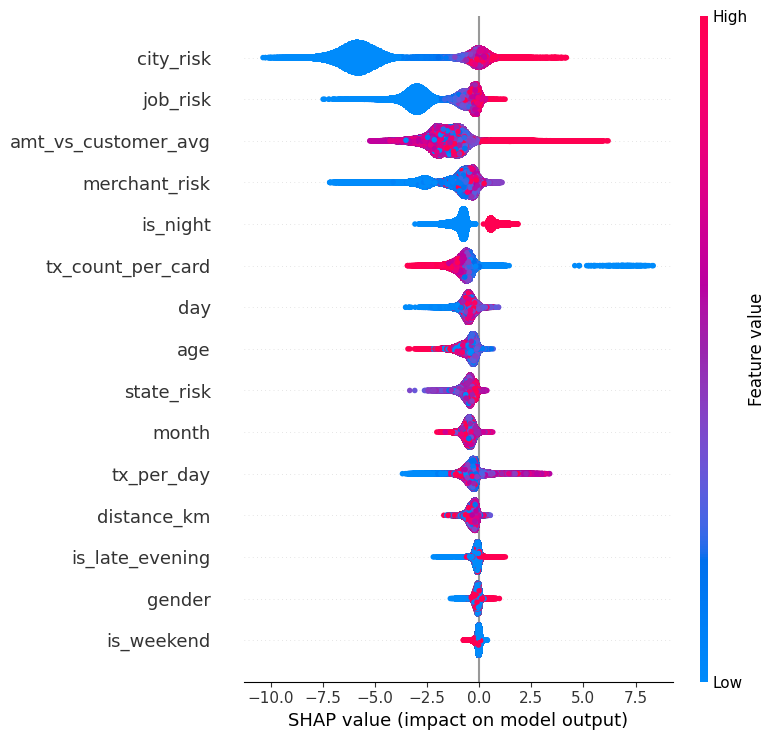

In [141]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_external)

# Summary plot
shap.summary_plot(shap_values, X_external)

To interpret the final XGBoost model and understand how predictions are made, SHAP (SHapley Additive exPlanations) was applied. SHAP values quantify the contribution of each feature toward increasing or decreasing the probability of fraud for individual transactions.

The SHAP summary plot provides two major insights:

- Feature importance ranking (ordered from most influential to least)
- Direction of impact (left decreases fraud probability, right increases fraud probability)

---
**Key Insights from SHAP Analysis**
1. **City Risk & Job Risk**
    - Higher `city_risk` values significantly increase fraud probability.
    - Higher `job_risk` values also push predictions toward fraud.
   
   **Interpretation**: Fraud is concentrated in specific geographic regions and job categories. These risk-based engineered features are highly predictive.

2. **Amount vs Customer Average (`amt_vs_customer_avg`)**
    - Transactions much higher than a customer's typical spending behavior strongly increase fraud probability.
    - Normal or lower-than-average transactions reduce fraud probability.
      
    **Interpretation**: Sudden deviations from usual spending behavior are strong fraud signals.

3. **Merchant Risk**
    - Higher `merchant_risk` increases the likelihood of fraud.
    - Indicates certain merchants historically show higher fraud patterns.

    **Interpretation**: Merchant-level historical fraud trends significantly influence predictions.

4. **Night Transactions (`is_night`)**
    - Night-time transactions increase fraud probability.
    - Day-time transactions reduce fraud probability.

    **Interpretation**: Fraudulent activities are more likely to occur during late-night hours.

5. **Transaction Frequency Features**
    - `tx_count_per_card` and `tx_per_day` moderately impact predictions.
    - Unusual transaction frequency patterns influence fraud detection.

6. **Lower Impact Features**

    Features such as:
    - `gender`
    - `is_weekend`
    - `distance_km`
    - `month`
    - `day`
   
    have relatively lower impact on model predictions.

## Overall Interpretation

The model primarily relies on:

- Behavioral deviation (amount compared to customer average)
- Geographic fraud concentration (city risk)
- Occupational risk (job risk)
- Merchant historical fraud patterns
- Night-time transaction behavior

This confirms that the model is capturing meaningful fraud behavior patterns rather than relying on irrelevant variables.

## Model Reliability

The SHAP interpretation demonstrates that:

- The model’s predictions are aligned with real-world fraud behavior.
- Feature importance is driven by logical and business-relevant variables.
- No unexpected or spurious features dominate the model.

This increases confidence in deploying the XGBoost model for real-world fraud detection scenarios.

# 13 - Business Impact Analysis

## Cost-Benefit Analysis

### Part I: Dataset Analysis

**1️⃣ Average number of transactions per month**

We need original dataset for this before splitting.

In [142]:
#train_data = "/content/drive/MyDrive/Credit_Card_Fraud_Detection/Data/raw/fraudTrain.csv"

#df_org = pd.read_csv(train_data)

df_org = pd.read_csv(r'C:\Users\tejas\Documents\Credit_Card_Fraud_Detection\Data\raw\fraudTrain.csv')

print("Shape of Train data: ", df_org.shape)

Shape of Train data:  (734993, 23)


In [143]:
# Convert to datetime
df_org['trans_date_trans_time'] = pd.to_datetime(df_org['trans_date_trans_time'])

# Extract month-year
df_org['year_month'] = df_org['trans_date_trans_time'].dt.to_period('M')

# Total transactions per month
monthly_transactions = df_org.groupby('year_month').size()

avg_transactions_per_month = int(monthly_transactions.mean())
print("Average number of transactions per month:", avg_transactions_per_month)

Average number of transactions per month: 66817


**2️⃣ Average number of fraudulent transactions per month**

In [144]:
monthly_fraud = df_org[df_org['is_fraud'] == 1].groupby('year_month').size()

avg_fraud_per_month = int(monthly_fraud.mean())
print("Average number of fraudulent transactions per month:", avg_fraud_per_month)

Average number of fraudulent transactions per month: 395


**3️⃣ Average amount per fraudulent transaction**

In [145]:
avg_fraud_amount = df_org[df_org['is_fraud'] == 1]['amt'].mean()
print("Average amount per fraudulent transaction:", round(avg_fraud_amount,4))

Average amount per fraudulent transaction: 526.3731


### Part II: Cost Before Model

**Before model:**

> Bank pays full fraud amount every time.
> 
> So the formula will be,
> 
> Cost incurred per month before the model was deployed = Average amount per fraudulent transaction * Average number of fraudulent transactions per month

In [146]:
cost_before = avg_fraud_amount * avg_fraud_per_month
print("Cost incurred per month before the model was deployed:",round(cost_before,4))

Cost incurred per month before the model was deployed: 207917.3935


### Part III: Cost After Model

Now we will use external test confusion matrix to evaluate cost after model is created.

In [147]:
cm = confusion_matrix(y_external, external_pred)

|             | Predicted: Non-Fraud | Predicted: Fraud |
|-------------|:--------------------:|:----------------:|
|**Actual: Non-Fraud** | 552871 | 703 |
|**Actual: Fraud** | 700 | 1445 |

So:
- TP = 1445
- FN = 700
- Total fraud = 2145

In [148]:
TN, FP, FN, TP = cm.ravel()

**Calculate Detection Rate**

In [149]:
recall = round((TP / (TP + FN)),4)
recall

0.6737

**Estimate monthly detected fraud (TF)**

In [150]:
TF = avg_fraud_per_month * recall
TF

266.1115

**Estimate missed fraud (FN)**

In [151]:
FN_monthly = round((avg_fraud_per_month * (1 - recall)),4)
FN_monthly

128.8885

**Cost of Customer Support**

Cost = $1.5 per detected fraud

In [152]:
cost_support = round((1.5 * TF),4)
cost_support

399.1672

**Cost of Undetected Fraud**

In [153]:
cost_missed = round((avg_fraud_amount * FN_monthly),4)
cost_missed

67843.4455

**Total Cost After Model**

In [154]:
cost_after = cost_support + cost_missed
cost_after

68242.6127

### Part IV: Final Savings

In [155]:
final_savings = round((cost_before - cost_after),4)
final_savings

139674.7808

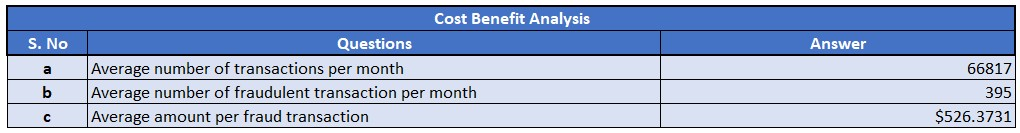

In [5]:
from IPython.display import Image
Image(filename="cost_benefit_analysis1.jpg", width=800)

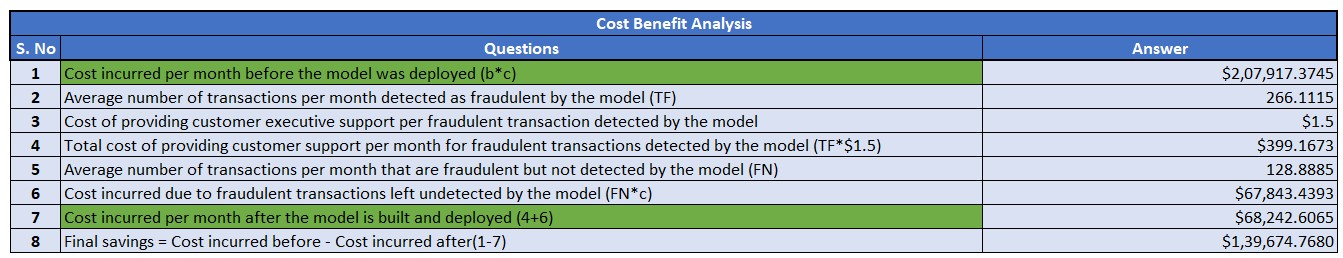

In [7]:
Image(filename="cost_benefit_analysis2.jpg", width=1000)

# 14 - Conclusion

This capstone project successfully developed and evaluated a machine learning-based fraud detection system aimed at minimizing financial losses due to fraudulent credit card transactions.

The project followed a structured and industry-aligned workflow:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Advanced feature engineering
- Multicollinearity checks
- Model building with multiple algorithms
- Class imbalance handling
- Hyperparameter tuning
- Model evaluation on internal and external test data
- Business impact and cost-benefit analysis

## Model Performance Summary

After comparing multiple models (Logistic Regression, Decision Tree, Random Forest, and XGBoost), XGBoost emerged as the final selected model due to:

- Strong ROC-AUC performance
- Better balance between fraud recall and precision
- Superior generalization on external unseen data

**External Test Performance**

- ROC-AUC: 0.9937
- Fraud Recall: 67%
- Fraud Precision: 67%
- Missed Fraud Cases Reduced Significantly**

The model demonstrated strong generalization capability on completely unseen external data, confirming that data leakage issues were successfully addressed and that the model is robust.

## Business Impact Analysis

From the cost-benefit evaluation:

- Average monthly fraudulent transactions: **395**
  
- Average fraud amount: **$526.37**

- Monthly fraud loss **before model**: **$207,917.39**

**After deploying the model:**

- Monthly cost of undetected fraud + authentication support: **$68,242.61**
  
- Estimated **monthly savings**: **$139,675**

- Approximate **annual savings**: **~$1.67 million**

This demonstrates that the model provides substantial financial benefit, even after accounting for the cost of secondary authentication ($1.5 per flagged transaction).

## Key Insights

- Fraud patterns are strongly influenced by time-based features (night transactions), transaction deviation from customer average, and geographic risk indicators.

- Ensemble tree-based models significantly outperform linear models in detecting complex fraud behavior.

- Proper handling of class imbalance and prevention of data leakage are critical for realistic performance estimation.

- Model threshold tuning plays a major role in balancing fraud detection vs false positives.

## Final Recommendation

The XGBoost model is recommended for deployment due to:

- High discriminatory power (ROC-AUC > 0.99 on external data)

- Strong fraud detection capability

- Significant reduction in financial loss

- Stable performance across datasets

Future improvements may include:

- Dynamic threshold optimization based on business risk tolerance

- Real-time monitoring and model retraining

- Continuous drift detection

## Overall Outcome

The project successfully demonstrates how machine learning can be translated into measurable business value.

The proposed fraud detection system is not only statistically strong but also financially impactful, offering significant cost savings and improved fraud risk management for the bank.